In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('/content/churn-bigml-80.csv')
print('Training data shape:', df_train.shape)
df_train.head()

Training data shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
df_test = pd.read_csv('/content/churn-bigml-20.csv')
print('Testing data shape:', df_test.shape)
df_test.head()

Testing data shape: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [4]:
# 1. Class Imbalance in 'Churn' column
print("Class Imbalance in 'Churn' column (Training Data):")
print(df_train['Churn'].value_counts(normalize=True))
print("\n")

# 2. Check for Missing Values
print("Missing Values in Training Data:")
missing_values_train = df_train.isnull().sum()
print(missing_values_train[missing_values_train > 0])
print("\n")

print("Missing Values in Test Data:")
missing_values_test = df_test.isnull().sum()
print(missing_values_test[missing_values_test > 0])

Class Imbalance in 'Churn' column (Training Data):
Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


Missing Values in Training Data:
Series([], dtype: int64)


Missing Values in Test Data:
Series([], dtype: int64)


Visualizing Feature Distributions and Correlation with Churn

--- Numerical Feature Distributions and Churn Relationship ---


/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


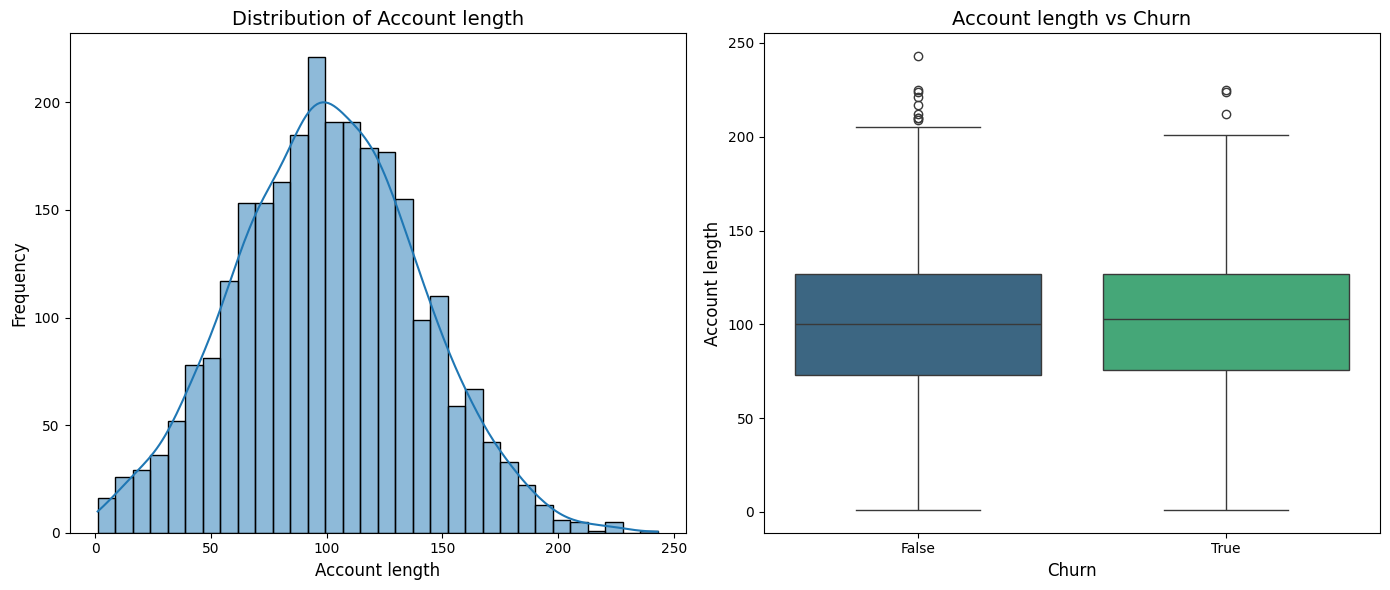

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


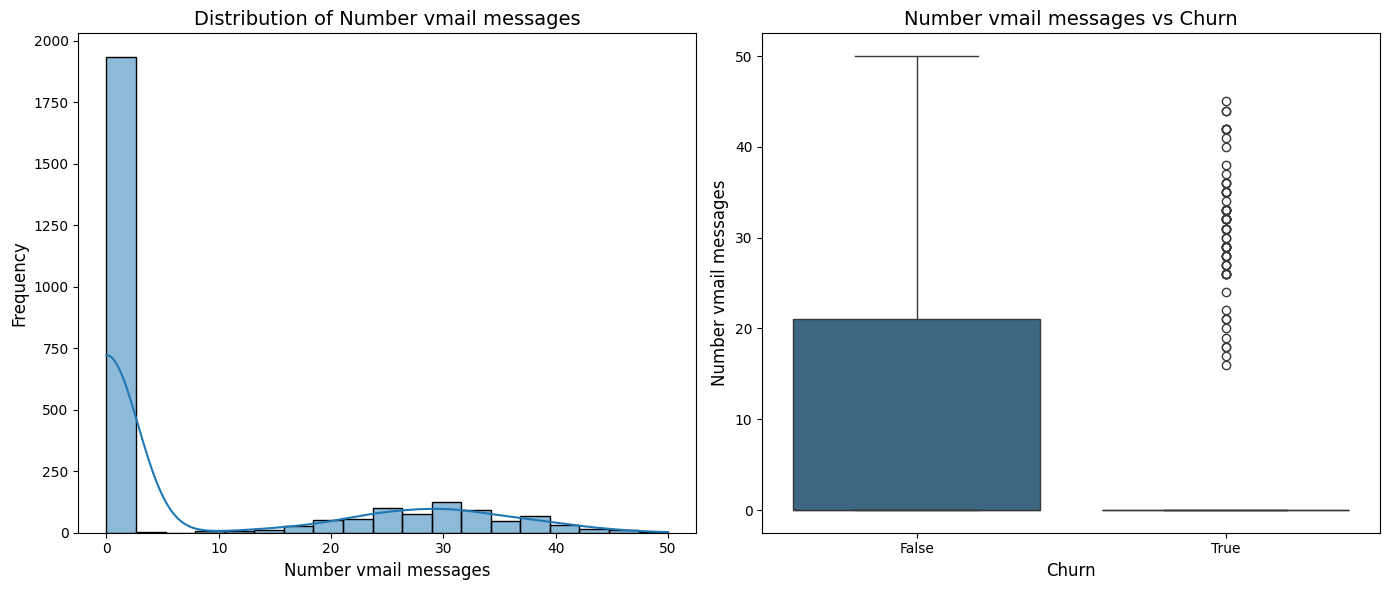

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


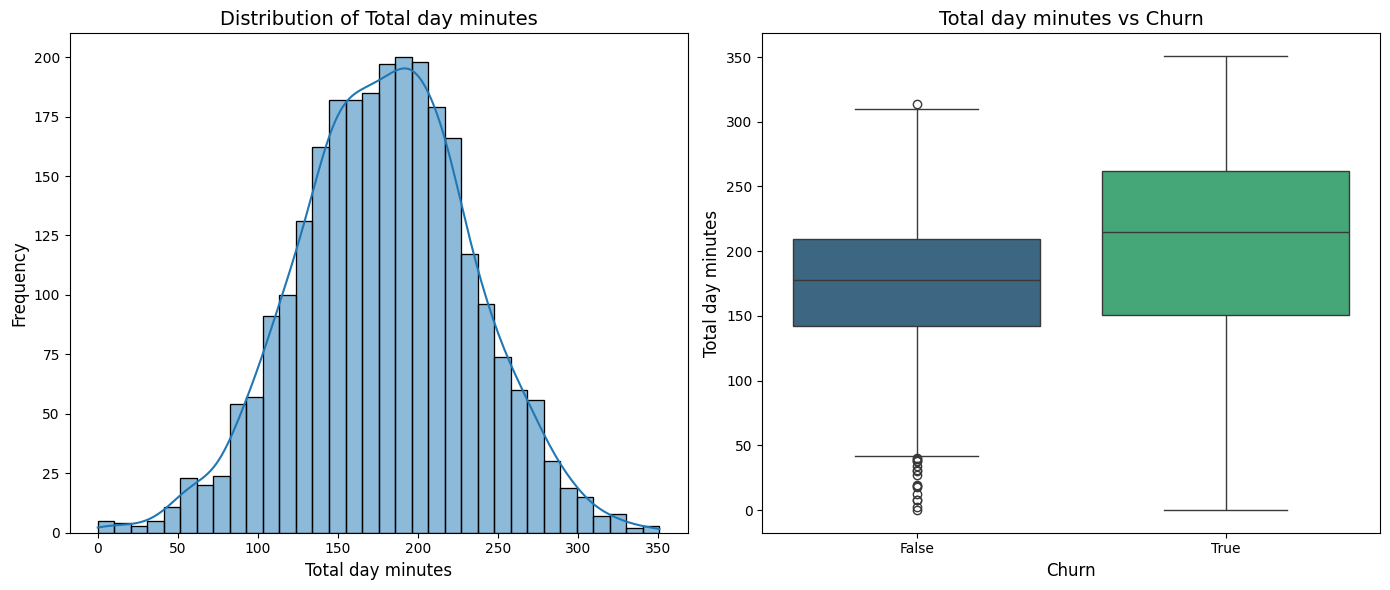

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


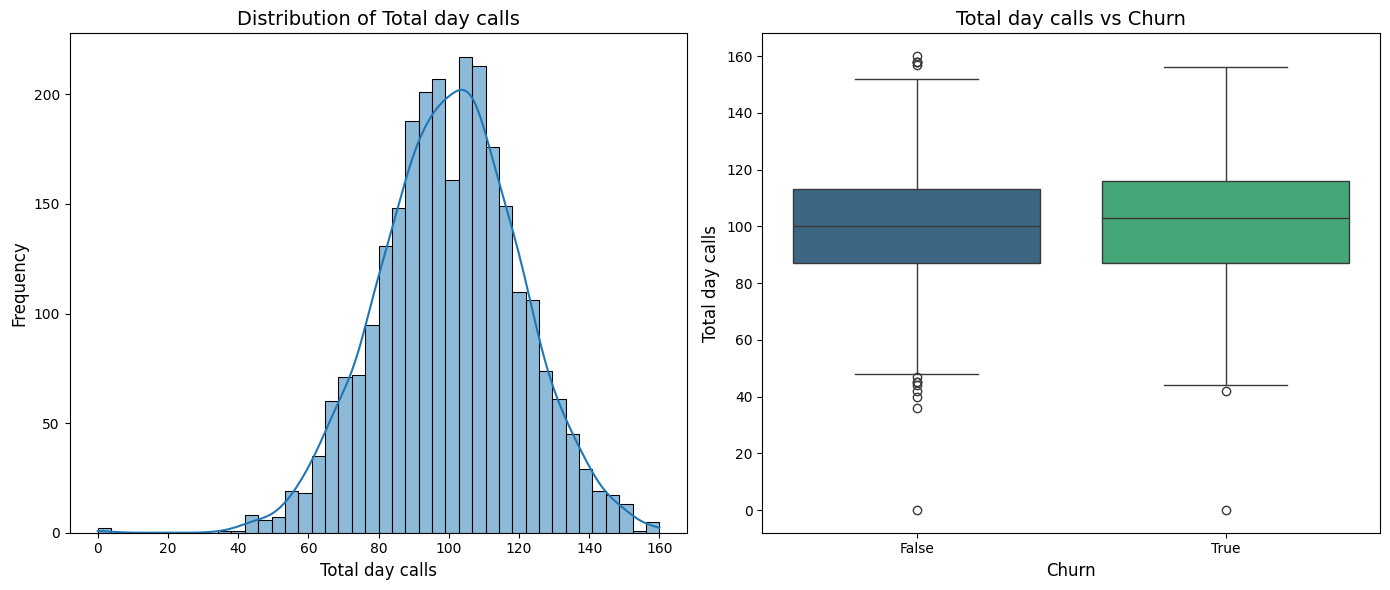

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


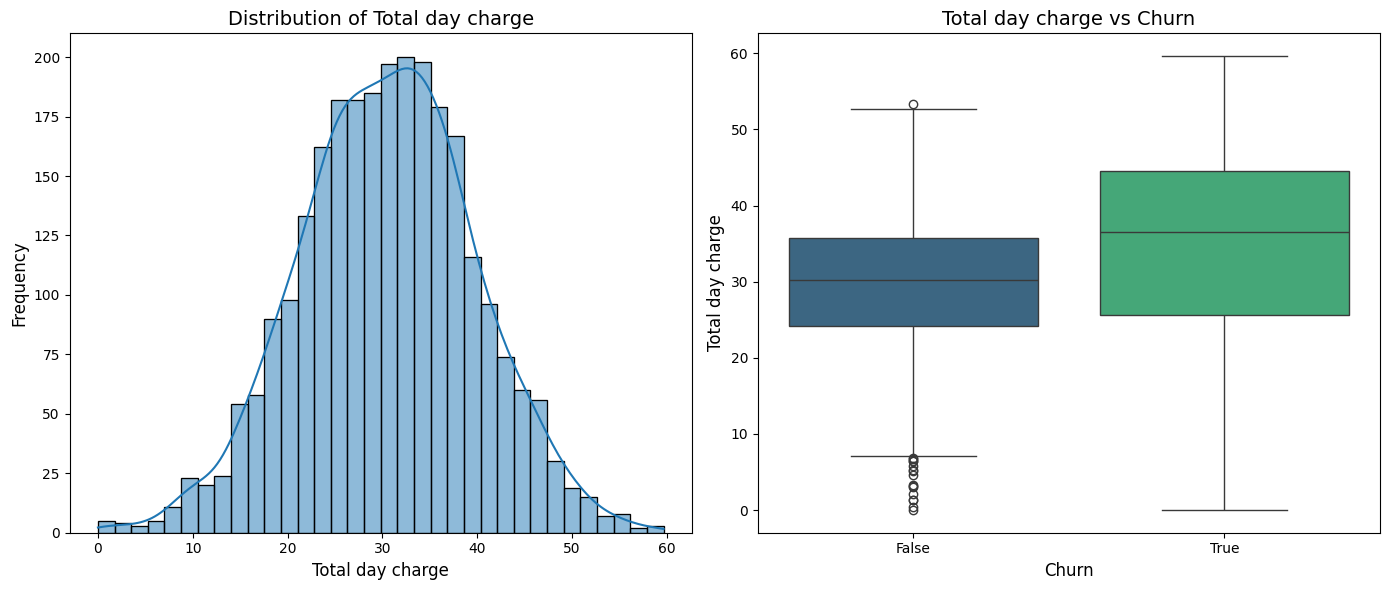

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


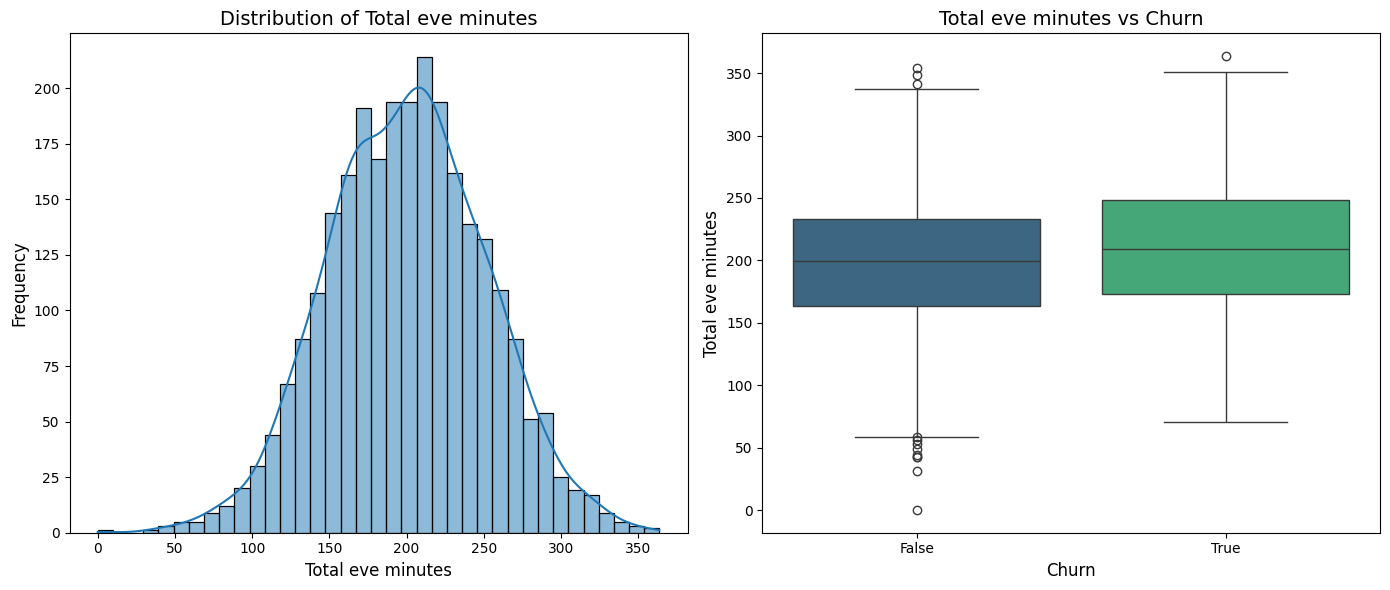

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


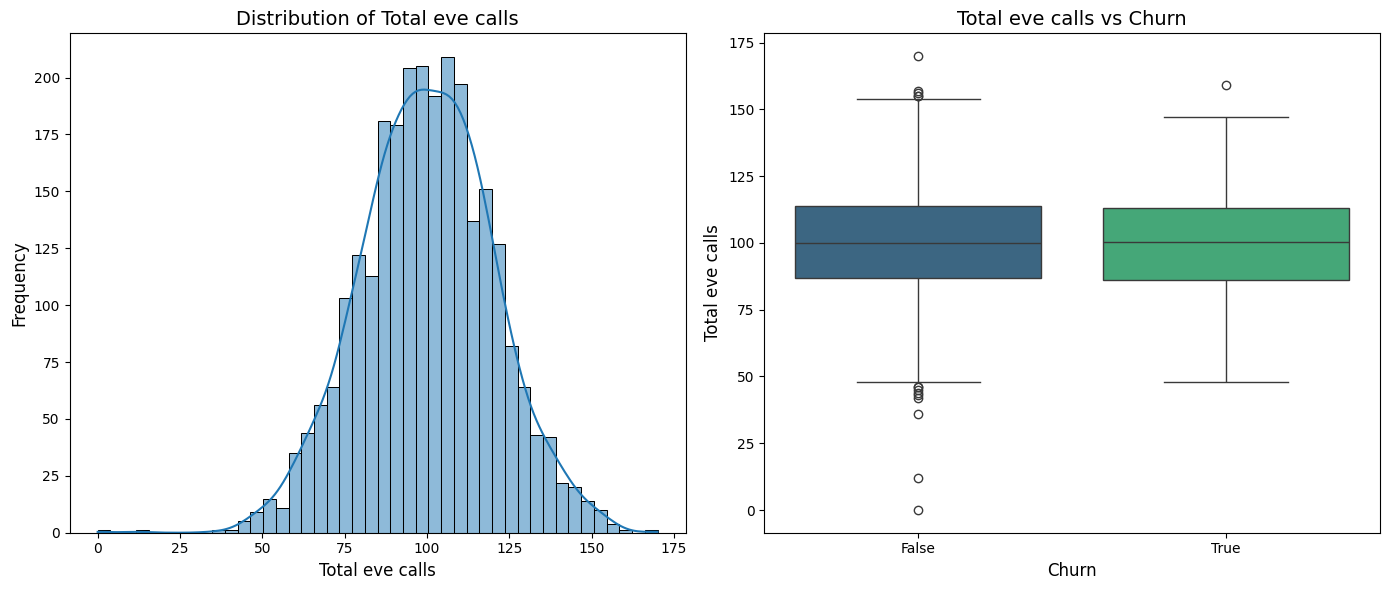

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


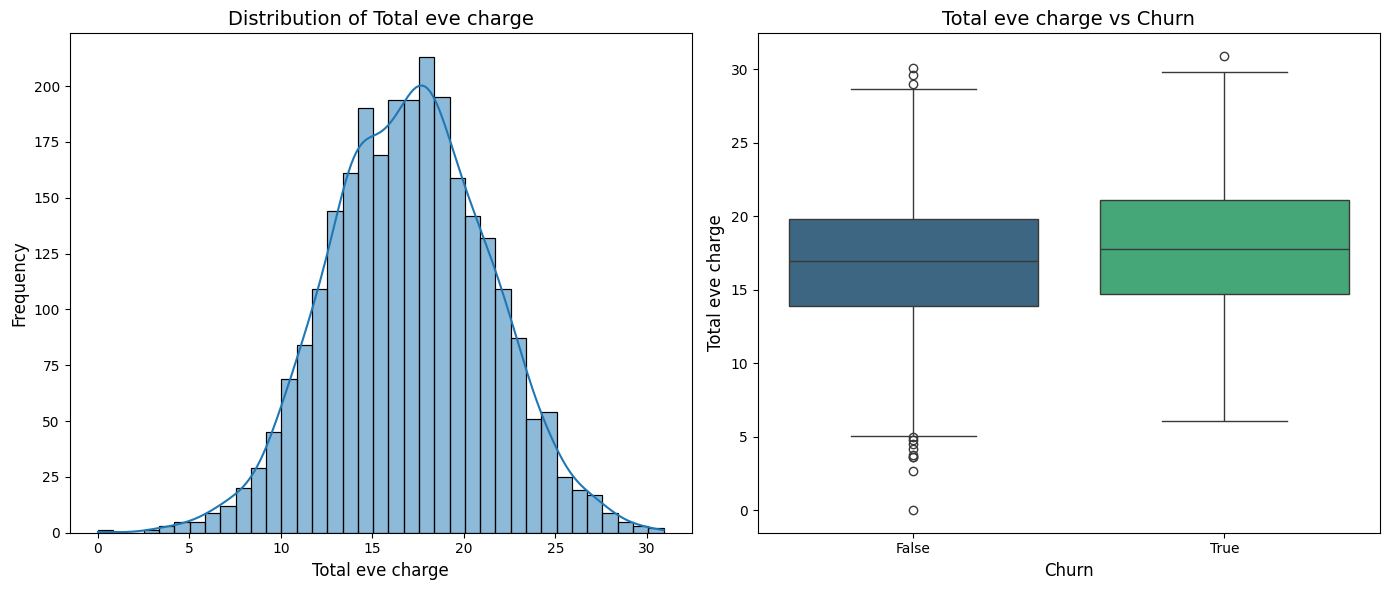

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


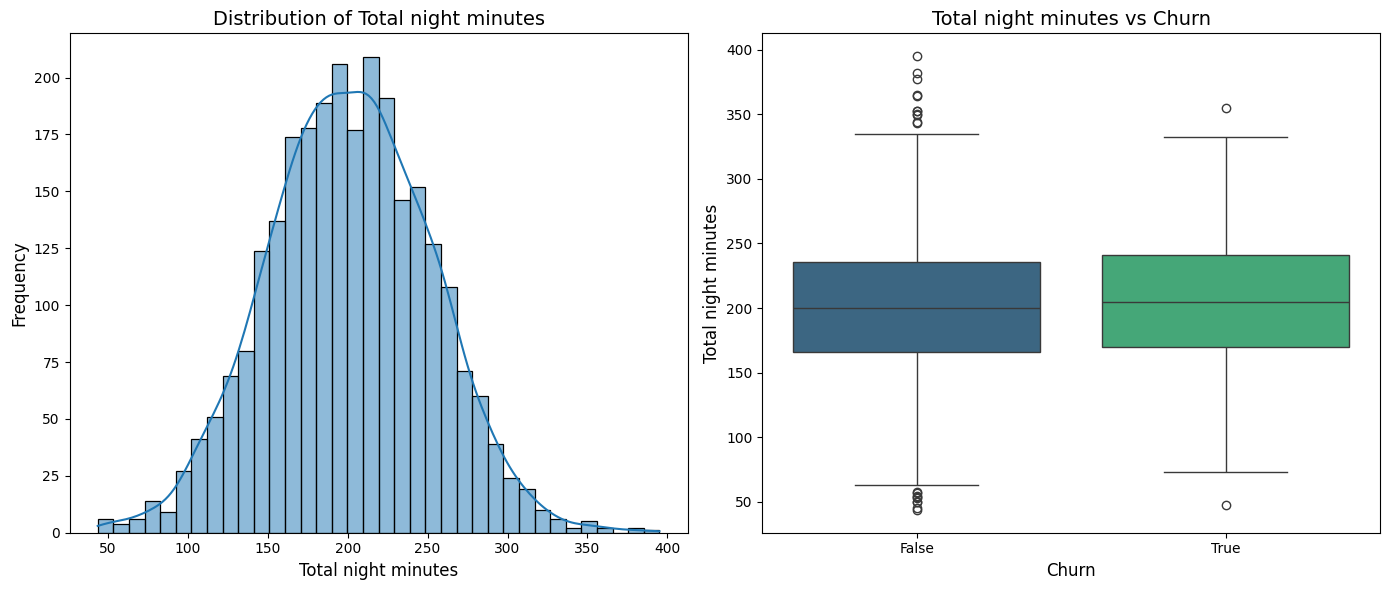

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


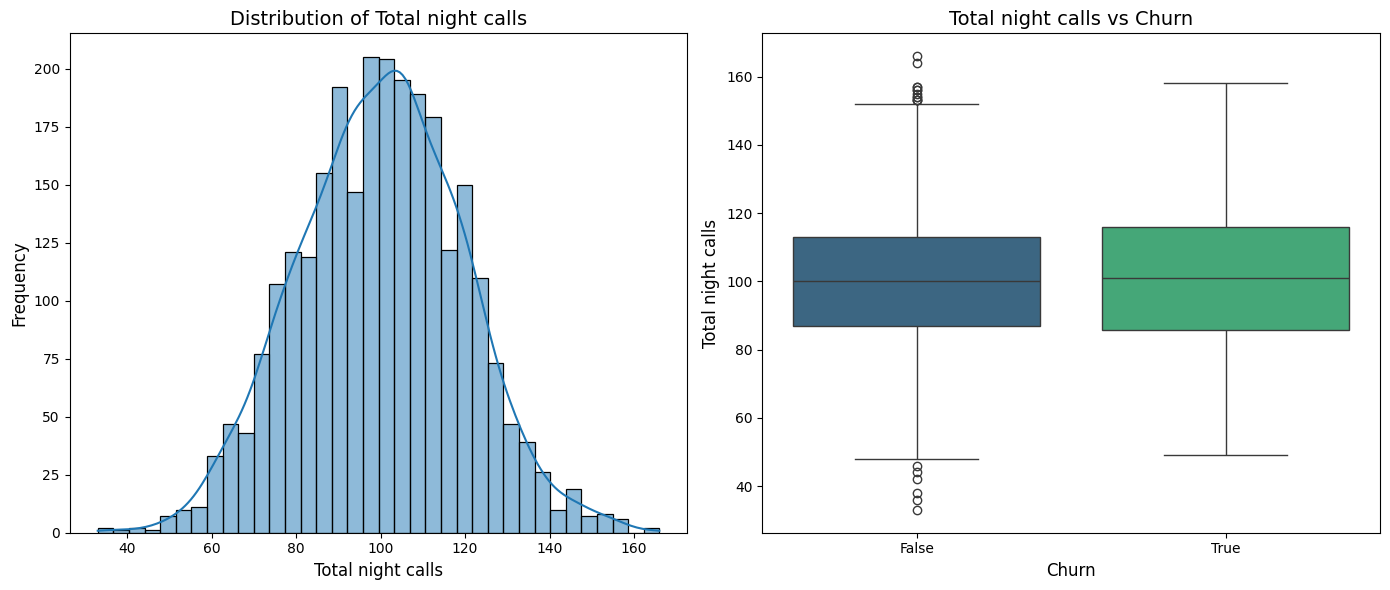

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


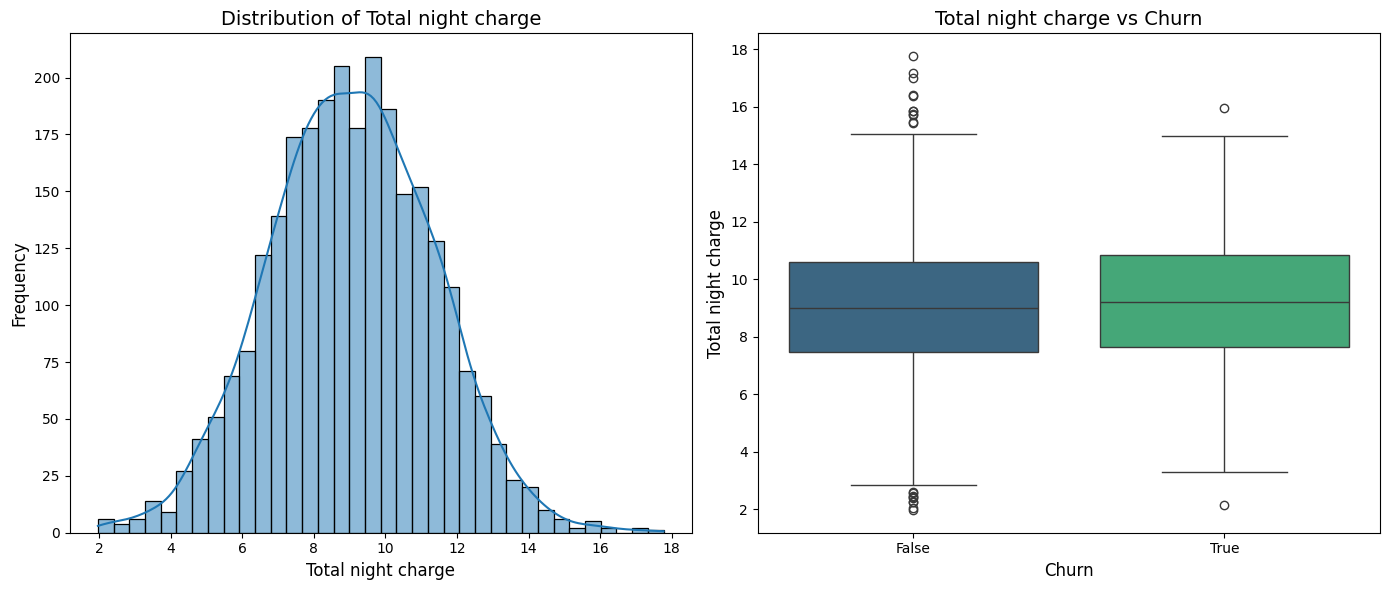

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


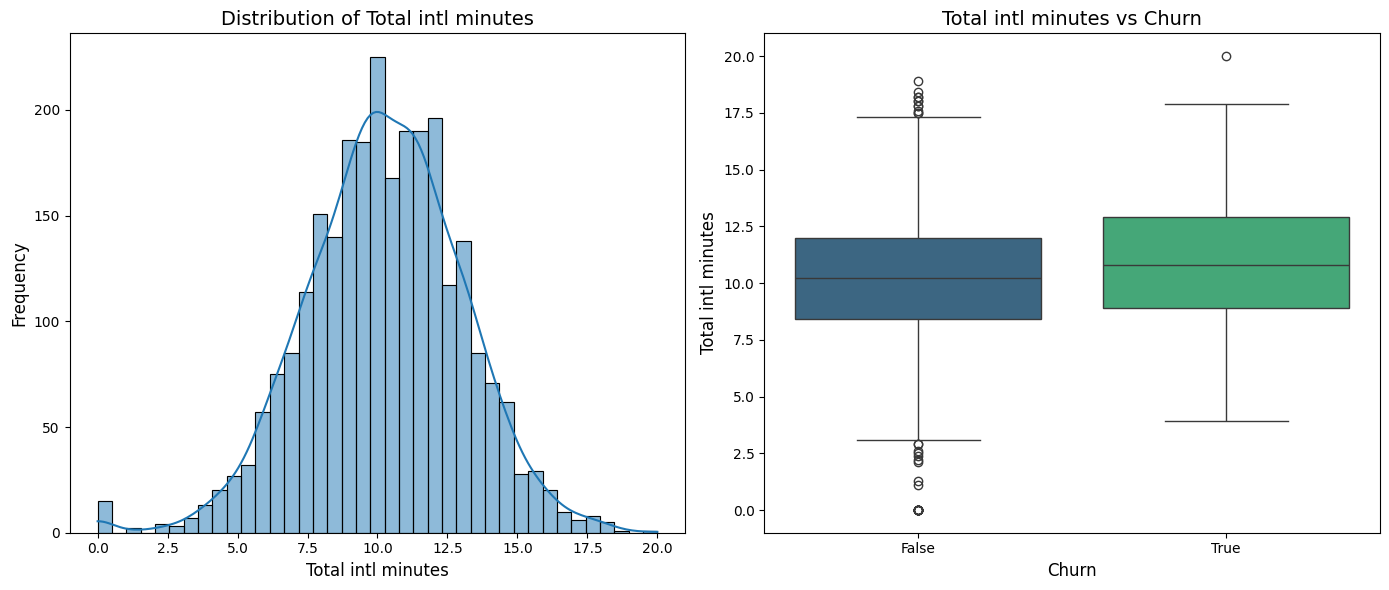

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


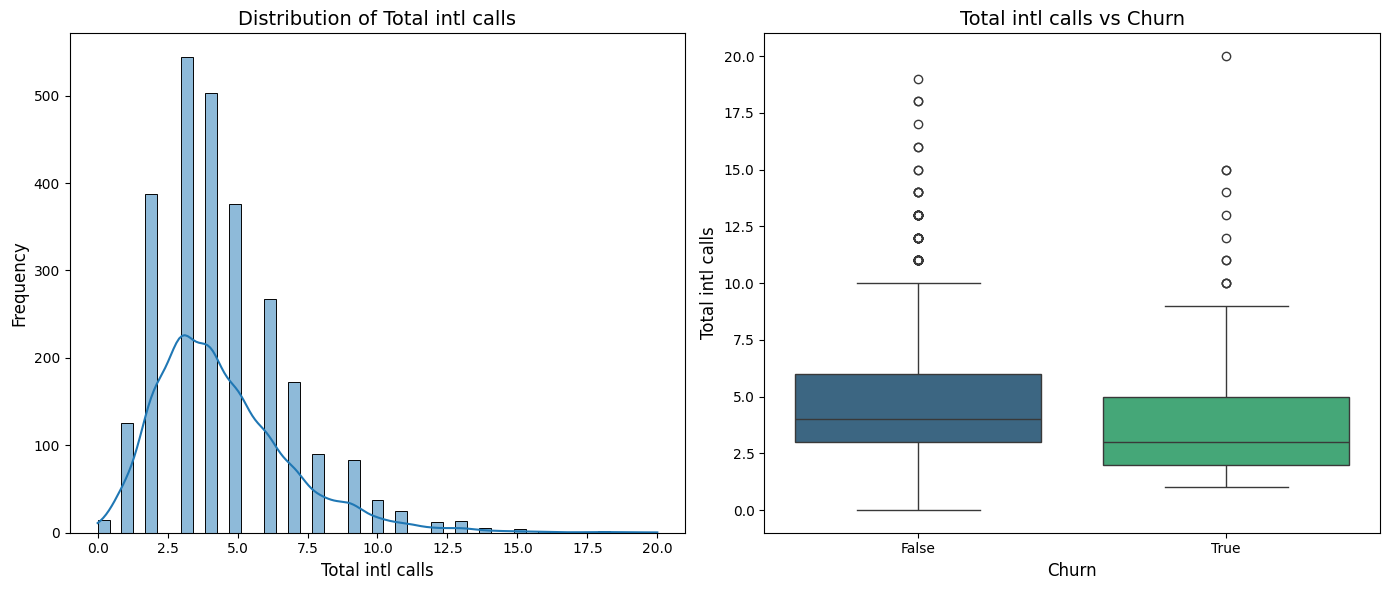

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


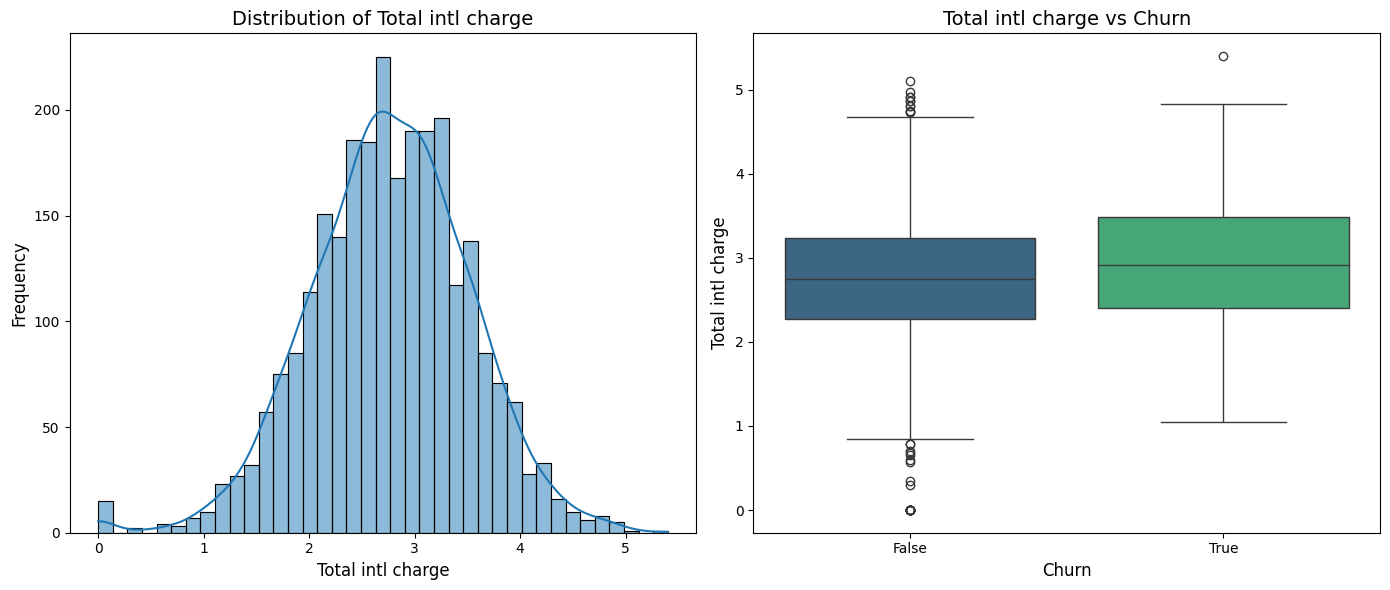

/tmp/ipykernel_34000/2635686303.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
/tmp/ipykernel_34000/2635686303.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')


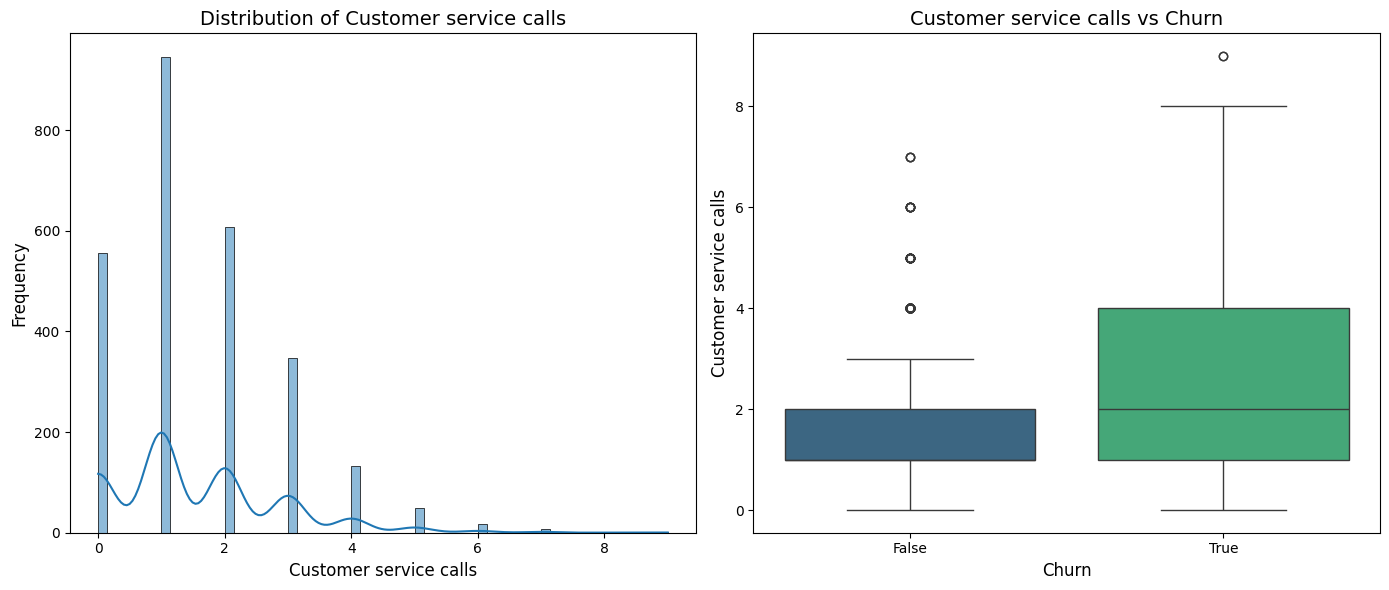


--- Categorical Feature Distributions and Churn Relationship ---


/tmp/ipykernel_34000/2635686303.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, palette='viridis')


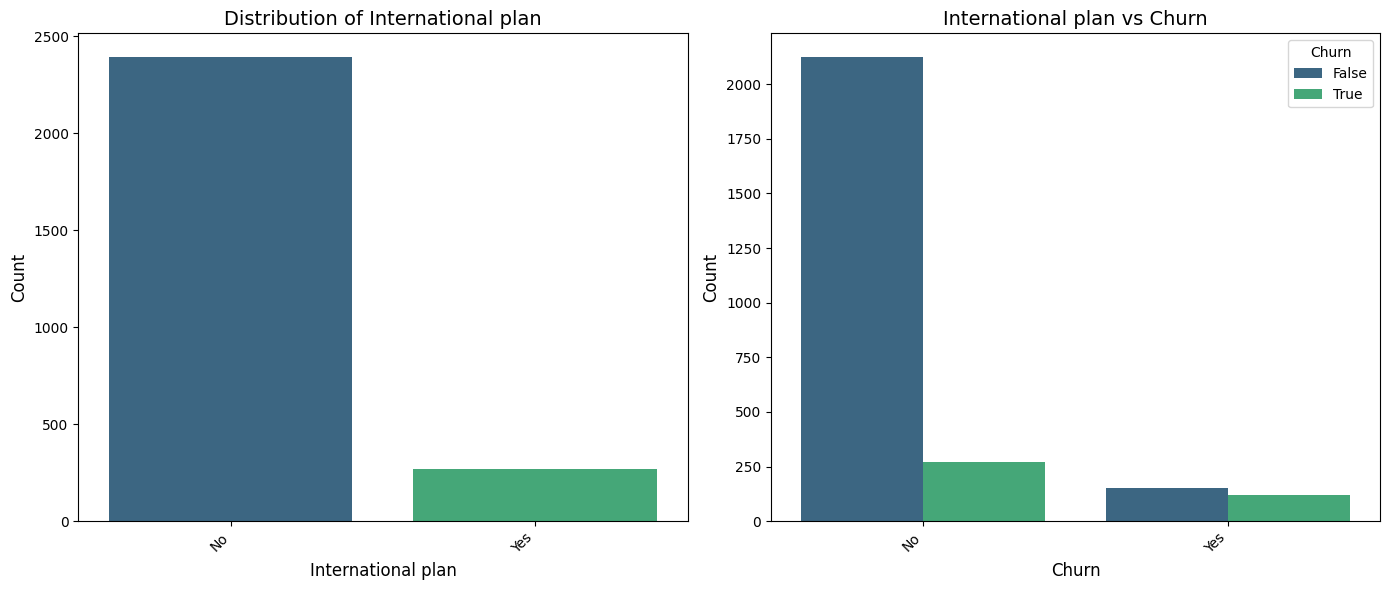

/tmp/ipykernel_34000/2635686303.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, palette='viridis')


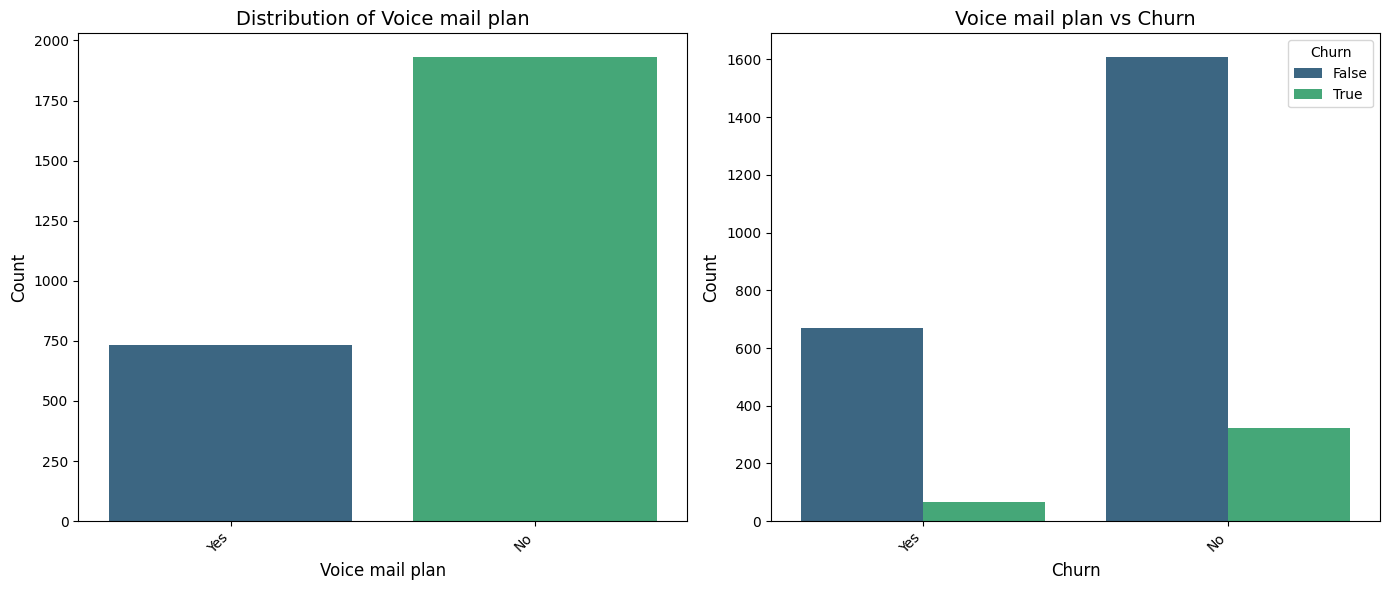

/tmp/ipykernel_34000/2635686303.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, palette='viridis')


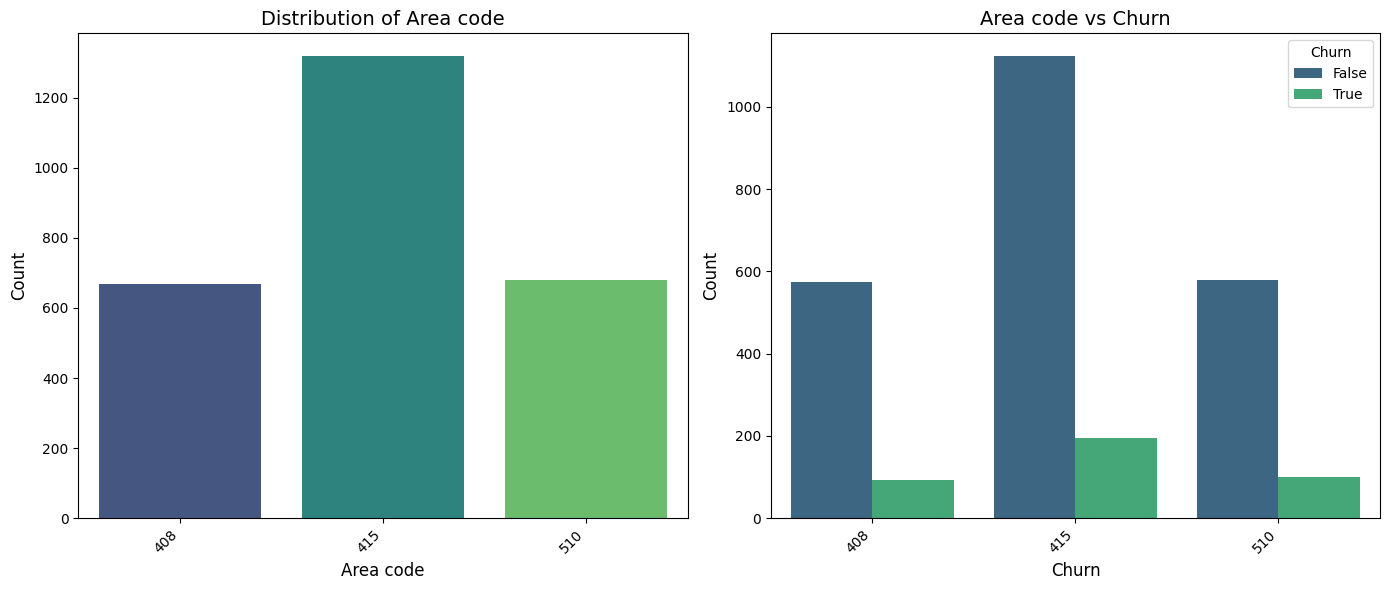


--- Correlation Matrix of Numerical Features with Churn ---


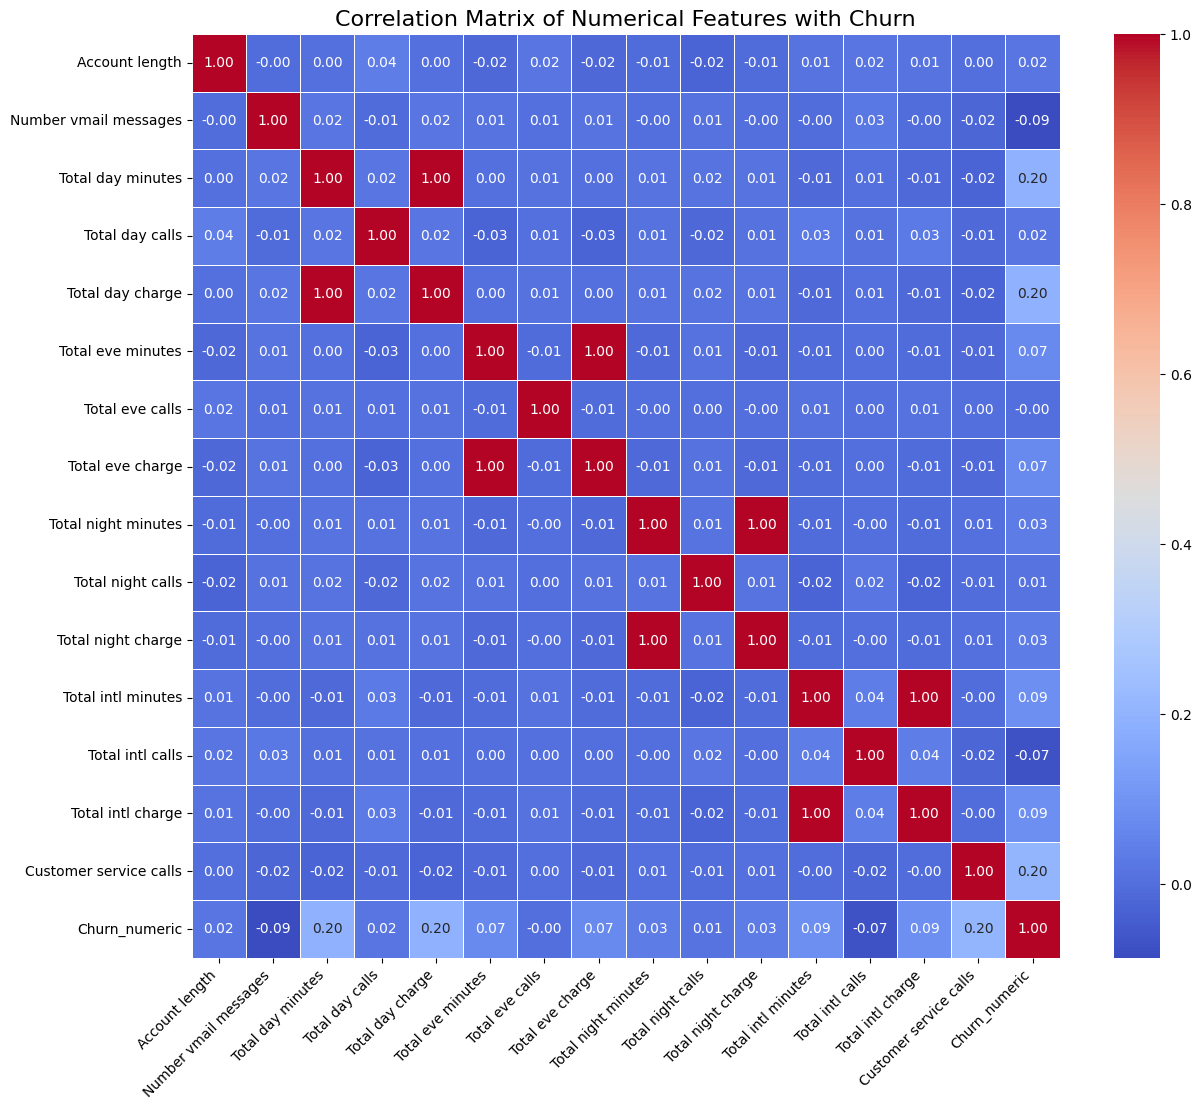

In [5]:
# Convert 'Churn' to numeric for easier plotting and correlation calculation if not already done
df_train['Churn_numeric'] = df_train['Churn'].astype(int)

# Identify numerical and categorical columns
numerical_cols = df_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_train.select_dtypes(include='object').columns.tolist()

# Remove target variable and 'Account length' and 'Area code' from numerical if they are better treated as categorical
# 'Account length' and 'Area code' are technically numbers but might be better treated as categories or distinct identifiers.
# For now, let's keep them and observe the plots. If they don't provide good insights, we can adjust.
if 'Churn_numeric' in numerical_cols:
    numerical_cols.remove('Churn_numeric')
# 'State', 'International plan', 'Voice mail plan' are typically categorical
# Ensure 'State', 'International plan', 'Voice mail plan' are in categorical_cols
# Check if 'Area code' should be categorical (it's discrete and represents regions)
if 'Area code' in numerical_cols:
    numerical_cols.remove('Area code')
    if 'Area code' not in categorical_cols:
        categorical_cols.append('Area code')

# Remove 'State' from categorical_cols for now, as it has too many unique values for count plots
# We can analyze 'State' separately if needed.
if 'State' in categorical_cols:
    categorical_cols.remove('State')

print("Visualizing Feature Distributions and Correlation with Churn")

# Plotting Numerical Features
print("\n--- Numerical Feature Distributions and Churn Relationship ---")
for col in numerical_cols:
    plt.figure(figsize=(14, 6))

    # Distribution plot
    plt.subplot(1, 2, 1)
    sns.histplot(data=df_train, x=col, kde=True, palette='viridis')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    # Box plot vs Churn
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_train, x='Churn', y=col, palette='viridis')
    plt.title(f'{col} vs Churn', fontsize=14)
    plt.xlabel('Churn', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.tight_layout()
    plt.show()

# Plotting Categorical Features
print("\n--- Categorical Feature Distributions and Churn Relationship ---")
for col in categorical_cols:
    plt.figure(figsize=(14, 6))

    # Count plot
    plt.subplot(1, 2, 1)
    sns.countplot(data=df_train, x=col, palette='viridis')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    # Count plot vs Churn (stacked or side-by-side)
    plt.subplot(1, 2, 2)
    sns.countplot(data=df_train, x=col, hue='Churn', palette='viridis')
    plt.title(f'{col} vs Churn', fontsize=14)
    plt.xlabel('Churn', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Churn')
    plt.tight_layout()
    plt.show()

# Correlation matrix for numerical features
print("\n--- Correlation Matrix of Numerical Features with Churn ---")
plt.figure(figsize=(14, 12))
correlation_matrix = df_train[numerical_cols + ['Churn_numeric']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features with Churn', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

# --- Data Cleaning & Preprocessing ---

# 1. Handle missing values: Already checked, no missing values found.

# Separate features (X) and target (y)
X_train = df_train.drop(['Churn', 'Churn_numeric'], axis=1)
y_train = df_train['Churn']

X_test = df_test.drop('Churn', axis=1)
y_test = df_test['Churn']

# Identify categorical and numerical columns for preprocessing
# We will re-identify them to ensure consistency and handle 'State' separately if needed
categorical_features = X_train.select_dtypes(include='object').columns.tolist()
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

# 'State' has too many unique values for simple one-hot encoding; remove for now or consider other encoding methods later.
if 'State' in categorical_features:
    categorical_features.remove('State')
    X_train = X_train.drop('State', axis=1)
    X_test = X_test.drop('State', axis=1)

# Convert 'Area code' to categorical if it's currently numerical, as it's a code, not a continuous value
if 'Area code' in numerical_features:
    numerical_features.remove('Area code')
    X_train['Area code'] = X_train['Area code'].astype(object)
    X_test['Area code'] = X_test['Area code'].astype(object)
    if 'Area code' not in categorical_features:
        categorical_features.append('Area code')

print(f"Categorical features selected for encoding: {categorical_features}")
print(f"Numerical features selected for scaling: {numerical_features}")

# 2. Encode categorical variables (One-hot encoding)
print("\nEncoding categorical variables...")
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

# Align columns - very important for test set after one-hot encoding
X_train_cols = set(X_train_encoded.columns)
X_test_cols = set(X_test_encoded.columns)

missing_in_test = list(X_train_cols - X_test_cols)
for c in missing_in_test:
    X_test_encoded[c] = 0

missing_in_train = list(X_test_cols - X_train_cols)
for c in missing_in_train:
    X_train_encoded[c] = 0

X_test_encoded = X_test_encoded[X_train_encoded.columns]

print("Categorical encoding complete. Shapes: ")
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")

# 3. Normalize numerical features (StandardScaler)
print("\nNormalizing numerical features...")
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train_scaled[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_scaled[numerical_features])

print("Numerical feature normalization complete.")

# 4. Remove duplicates (from training data only, typically)
print("\nChecking and removing duplicates...")
initial_train_rows = X_train_scaled.shape[0]
combined_train_df = pd.concat([X_train_scaled, y_train.reset_index(drop=True)], axis=1)
duplicates_before = combined_train_df.duplicated().sum()
combined_train_df.drop_duplicates(inplace=True)
final_train_rows = combined_train_df.shape[0]
X_train_preprocessed = combined_train_df.drop('Churn', axis=1)
y_train_preprocessed = combined_train_df['Churn']

if duplicates_before > 0:
    print(f"Removed {duplicates_before} duplicate rows from training data.")
    print(f"Training data shape after removing duplicates: {X_train_preprocessed.shape}")
else:
    print("No duplicate rows found in training data.")

# Assign processed dataframes back to more general names for clarity
X_train = X_train_preprocessed
y_train = y_train_preprocessed
X_test = X_test_scaled # No duplicates removed from test set to simulate real-world new data

print("\nData Cleaning & Preprocessing complete!")
print(f"Final X_train shape: {X_train.shape}")
print(f"Final y_train shape: {y_train.shape}")
print(f"Final X_test shape: {X_test.shape}")
print(f"Final y_test shape: {y_test.shape}")

Categorical features selected for encoding: ['International plan', 'Voice mail plan', 'Area code']
Numerical features selected for scaling: ['Account length', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']

Encoding categorical variables...
Categorical encoding complete. Shapes: 
X_train_encoded shape: (2666, 19)
X_test_encoded shape: (667, 19)

Normalizing numerical features...
Numerical feature normalization complete.

Checking and removing duplicates...
No duplicate rows found in training data.

Data Cleaning & Preprocessing complete!
Final X_train shape: (2666, 19)
Final y_train shape: (2666,)
Final X_test shape: (667, 19)
Final y_test shape: (667,)


In [7]:
# --- Handle Class Imbalance using SMOTE ---
import pandas as pd
from imblearn.over_sampling import SMOTE

print("Original class distribution in training data (y_train):")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE (y_train_resampled):")
print(y_train_resampled.value_counts())

print("\nSMOTE applied successfully!")
print(f"X_train_resampled shape: {X_train_resampled.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")

Original class distribution in training data (y_train):
Churn
False    2278
True      388
Name: count, dtype: int64

Class distribution after SMOTE (y_train_resampled):
Churn
False    2278
True     2278
Name: count, dtype: int64

SMOTE applied successfully!
X_train_resampled shape: (4556, 19)
y_train_resampled shape: (4556,)


In [8]:
import numpy as np
import pandas as pd

def create_powerful_features(df):
    df_fe = df.copy()

    # 1. Total Charges (Avg monthly spend proxy)
    charge_cols = ['Total day charge', 'Total eve charge', 'Total night charge', 'Total intl charge']
    df_fe['Total_Charge'] = df_fe[charge_cols].sum(axis=1)

    # 2. Total Minutes & Total Calls
    minutes_cols = ['Total day minutes', 'Total eve minutes', 'Total night minutes', 'Total intl minutes']
    df_fe['Total_Minutes'] = df_fe[minutes_cols].sum(axis=1)

    calls_cols = ['Total day calls', 'Total eve calls', 'Total night calls', 'Total intl calls']
    df_fe['Total_Calls'] = df_fe[calls_cols].sum(axis=1)

    # 3. Average Charge per Minute (Overall)
    df_fe['Avg_Charge_Per_Minute'] = df_fe['Total_Charge'] / df_fe['Total_Minutes']
    df_fe['Avg_Charge_Per_Minute'] = df_fe['Avg_Charge_Per_Minute'].replace([np.inf, -np.inf], np.nan).fillna(0)

    # 4. Tenure Groups (numerical representation from scaled 'Account length')
    if df_fe['Account length'].nunique() > 1:
        df_fe['Tenure_Group_Numeric'] = pd.qcut(df_fe['Account length'], q=4, labels=False, duplicates='drop')
    else:
        df_fe['Tenure_Group_Numeric'] = 0

    # 5. Voicemail Usage Intensity (scaled vmail messages / scaled account length)
    df_fe['Voicemail_Per_Tenure'] = df_fe['Number vmail messages'] / df_fe['Account length']
    df_fe['Voicemail_Per_Tenure'] = df_fe['Voicemail_Per_Tenure'].replace([np.inf, -np.inf], np.nan).fillna(0)

    # 6. Customer Service Call Intensity (scaled customer service calls / scaled account length)
    df_fe['Customer_Service_Calls_Per_Tenure'] = df_fe['Customer service calls'] / df_fe['Account length']
    df_fe['Customer_Service_Calls_Per_Tenure'] = df_fe['Customer_Service_Calls_Per_Tenure'].replace([np.inf, -np.inf], np.nan).fillna(0)

    # 7. Interaction: International Plan and International Usage
    if 'International plan_Yes' in df_fe.columns:
        df_fe['Intl_Plan_and_Usage'] = df_fe['International plan_Yes'] * df_fe['Total intl minutes']
    else:
        df_fe['Intl_Plan_and_Usage'] = 0

    # 8. Usage Ratios based on total minutes
    df_fe['Day_Usage_Ratio'] = df_fe['Total day minutes'] / df_fe['Total_Minutes']
    df_fe['Eve_Usage_Ratio'] = df_fe['Total eve minutes'] / df_fe['Total_Minutes']
    df_fe['Night_Usage_Ratio'] = df_fe['Total night minutes'] / df_fe['Total_Minutes']
    df_fe['Intl_Usage_Ratio'] = df_fe['Total intl minutes'] / df_fe['Total_Minutes']

    # Handle division by zero for usage ratios
    for col in ['Day_Usage_Ratio', 'Eve_Usage_Ratio', 'Night_Usage_Ratio', 'Intl_Usage_Ratio']:
        df_fe[col] = df_fe[col].replace([np.inf, -np.inf], np.nan).fillna(0)

    return df_fe

# Apply feature engineering to training and test sets
X_train_fe = create_powerful_features(X_train_resampled)
X_test_fe = create_powerful_features(X_test)

print("Feature Engineering Complete!")
print(f"X_train_fe shape: {X_train_fe.shape}")
print(f"X_test_fe shape: {X_test_fe.shape}")

print("\nNew features added to X_train_fe:")
new_cols_train = [col for col in X_train_fe.columns if col not in X_train_resampled.columns]
print(new_cols_train)
print("\nNew features added to X_test_fe:")
new_cols_test = [col for col in X_test_fe.columns if col not in X_test.columns]
print(new_cols_test)

Feature Engineering Complete!
X_train_fe shape: (4556, 31)
X_test_fe shape: (667, 31)

New features added to X_train_fe:
['Total_Charge', 'Total_Minutes', 'Total_Calls', 'Avg_Charge_Per_Minute', 'Tenure_Group_Numeric', 'Voicemail_Per_Tenure', 'Customer_Service_Calls_Per_Tenure', 'Intl_Plan_and_Usage', 'Day_Usage_Ratio', 'Eve_Usage_Ratio', 'Night_Usage_Ratio', 'Intl_Usage_Ratio']

New features added to X_test_fe:
['Total_Charge', 'Total_Minutes', 'Total_Calls', 'Avg_Charge_Per_Minute', 'Tenure_Group_Numeric', 'Voicemail_Per_Tenure', 'Customer_Service_Calls_Per_Tenure', 'Intl_Plan_and_Usage', 'Day_Usage_Ratio', 'Eve_Usage_Ratio', 'Night_Usage_Ratio', 'Intl_Usage_Ratio']


In [9]:
# Install necessary libraries if not already installed
%pip install xgboost lightgbm scikit-learn imbalanced-learn

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported and checked for installation.")

Libraries imported and checked for installation.


In [10]:
# Define the models to train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, objective='binary')
}

# Dictionary to store results
results = {}

print("Starting model training and evaluation...")

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_fe, y_train_resampled)

    # Evaluate on Training Set
    y_pred_train = model.predict(X_train_fe)
    y_proba_train = model.predict_proba(X_train_fe)[:, 1]

    accuracy_train = accuracy_score(y_train_resampled, y_pred_train)
    precision_train = precision_score(y_train_resampled, y_pred_train)
    recall_train = recall_score(y_train_resampled, y_pred_train)
    f1_train = f1_score(y_train_resampled, y_pred_train)
    roc_auc_train = roc_auc_score(y_train_resampled, y_proba_train)

    # Evaluate on Test Set
    y_pred_test = model.predict(X_test_fe)
    y_proba_test = model.predict_proba(X_test_fe)[:, 1] # Probability of the positive class

    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test)
    recall_test = recall_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    roc_auc_test = roc_auc_score(y_test, y_proba_test)
    cm_test = confusion_matrix(y_test, y_pred_test)

    results[name] = {
        'Train Accuracy': accuracy_train,
        'Train Precision': precision_train,
        'Train Recall': recall_train,
        'Train F1-Score': f1_train,
        'Train ROC AUC': roc_auc_train,
        'Test Accuracy': accuracy_test,
        'Test Precision': precision_test,
        'Test Recall': recall_test,
        'Test F1-Score': f1_test,
        'Test ROC AUC': roc_auc_test,
        'Test Confusion Matrix': cm_test,
        'Test Classification Report': classification_report(y_test, y_pred_test)
    }

    print(f"{name} Performance (Training Set):")
    print(f"  Accuracy: {accuracy_train:.4f}")
    print(f"  Precision: {precision_train:.4f}")
    print(f"  Recall: {recall_train:.4f}")
    print(f"  F1-Score: {f1_train:.4f}")
    print(f"  ROC AUC: {roc_auc_train:.4f}")

    print(f"{name} Performance (Test Set):")
    print(f"  Accuracy: {accuracy_test:.4f}")
    print(f"  Precision: {precision_test:.4f}")
    print(f"  Recall: {recall_test:.4f}")
    print(f"  F1-Score: {f1_test:.4f}")
    print(f"  ROC AUC: {roc_auc_test:.4f}")
    print("  Confusion Matrix:\n", cm_test)
    print("  Classification Report:\n", classification_report(y_test, y_pred_test))

print("\nAll models trained and evaluated.")

Starting model training and evaluation...

--- Training Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Logistic Regression Performance (Training Set):
  Accuracy: 0.8036
  Precision: 0.8005
  Recall: 0.8086
  F1-Score: 0.8045
  ROC AUC: 0.8718
Logistic Regression Performance (Test Set):
  Accuracy: 0.7871
  Precision: 0.3672
  Recall: 0.6842
  F1-Score: 0.4779
  ROC AUC: 0.8032
  Confusion Matrix:
 [[460 112]
 [ 30  65]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.94      0.80      0.87       572
        True       0.37      0.68      0.48        95

    accuracy                           0.79       667
   macro avg       0.65      0.74      0.67       667
weighted avg       0.86      0.79      0.81       667


--- Training Random Forest ---
Random Forest Performance (Training Set):
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC AUC: 1.0000
Random Forest Performance (Test Set):
  Accuracy: 0.9430
  Precision: 0.7938
  Recall: 0.8105
  F1-Score: 0.8021
  ROC AUC: 0.9174
  Confusion Matrix:
 [[552 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:48:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Performance (Training Set):
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC AUC: 1.0000
XGBoost Performance (Test Set):
  Accuracy: 0.9610
  Precision: 0.8966
  Recall: 0.8211
  F1-Score: 0.8571
  ROC AUC: 0.9199
  Confusion Matrix:
 [[563   9]
 [ 17  78]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.98      0.98       572
        True       0.90      0.82      0.86        95

    accuracy                           0.96       667
   macro avg       0.93      0.90      0.92       667
weighted avg       0.96      0.96      0.96       667


--- Training LightGBM ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2278, number of negative: 2278
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004512 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] 

### Model Performance Comparison
Let's visualize the key performance metrics across all trained models to easily compare them.

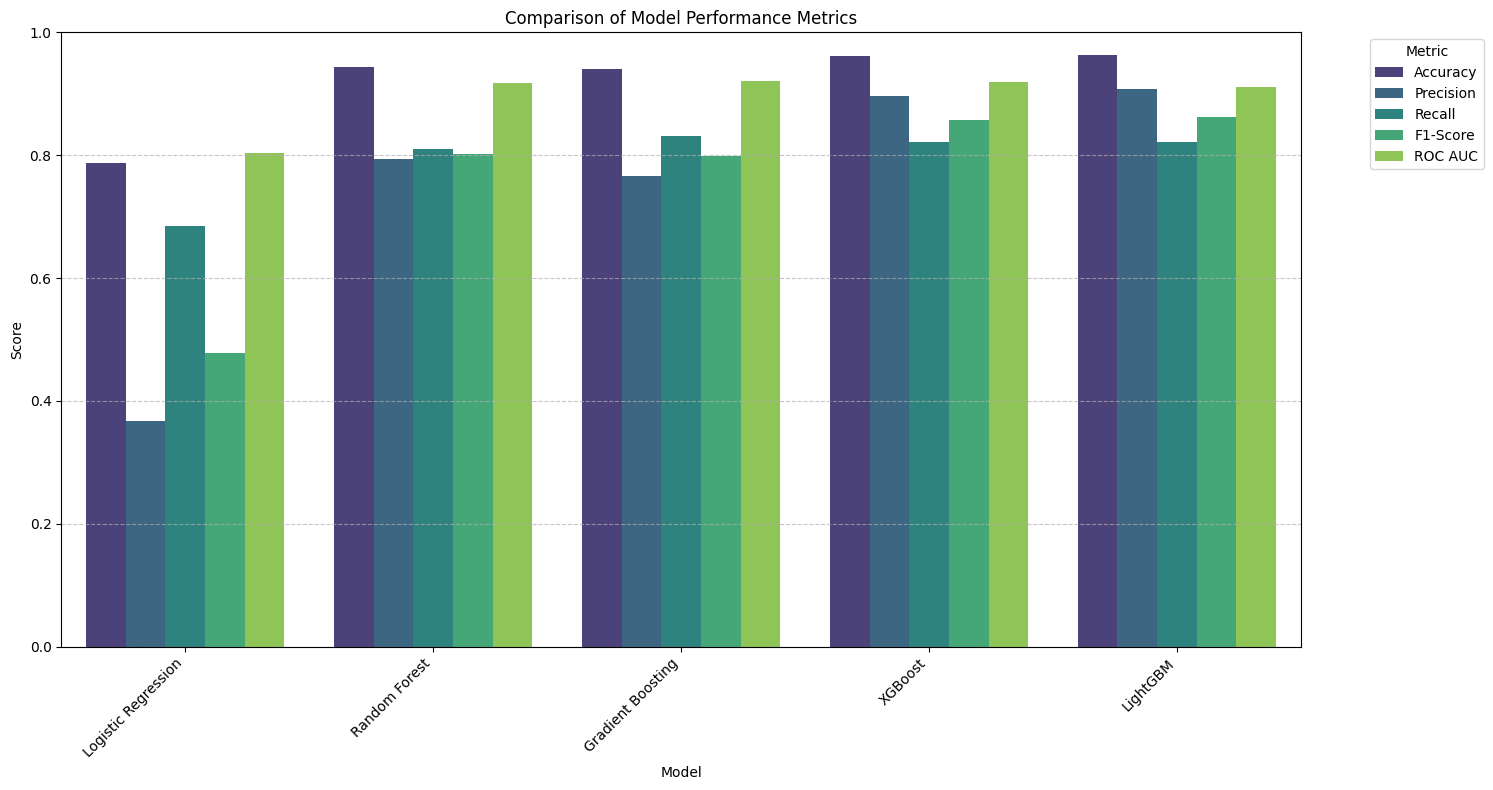

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Model,,,,,
Logistic Regression,0.787106,0.367232,0.684211,0.477941,0.803239
Random Forest,0.943028,0.793814,0.810526,0.802083,0.917437
Gradient Boosting,0.940030,0.766990,0.831579,0.797980,0.920648
XGBoost,0.961019,0.896552,0.821053,0.857143,0.919893
LightGBM,0.962519,0.906977,0.821053,0.861878,0.911538


In [11]:
# Prepare data for plotting
metrics_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [res['Test Accuracy'] for res in results.values()],
    'Precision': [res['Test Precision'] for res in results.values()],
    'Recall': [res['Test Recall'] for res in results.values()],
    'F1-Score': [res['Test F1-Score'] for res in results.values()],
    'ROC AUC': [res['Test ROC AUC'] for res in results.values()]
})

metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Display the detailed metrics table
display(metrics_df.set_index('Model'))


In [12]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.6 MB/s eta 0:00:00


In [13]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("Starting Hyperparameter Tuning with Optuna for LightGBM...")

def objective(trial):
    """Objective function for Optuna to optimize LightGBM hyperparameters."""

    # Define hyperparameter search space
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 60, step=5), # Related to tree depth
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100, step=10),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 10.0), # L1 regularization
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 10.0), # L2 regularization
        'random_state': 42,
        'n_jobs': -1, # Use all available cores
        'verbose': -1 # Suppress verbose output
    }

    model = LGBMClassifier(**params)

    # Use Stratified K-Fold Cross-Validation for robust evaluation
    # Given the class imbalance even after SMOTE, StratifiedKFold is good.
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    roc_auc_scores = []

    # Ensure X_train_fe is used for consistency with feature engineering
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fe, y_train_resampled)):
        X_train_fold, X_val_fold = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_resampled.iloc[train_idx], y_train_resampled.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1]
        roc_auc_scores.append(roc_auc_score(y_val_fold, y_pred_proba))

    # Return the average ROC AUC score across folds
    return np.mean(roc_auc_scores)

# Create an Optuna study and optimize
# 'direction="maximize"' because we want to maximize ROC AUC
study = optuna.create_study(direction='maximize', study_name='LGBM_Hyperparameter_Optimization')
study.optimize(objective, n_trials=50) # You can adjust n_trials for more exhaustive search

print("\nHyperparameter Tuning Complete!")
print("Number of finished trials: ", len(study.trials))
print("Best trial:")

trial = study.best_trial

print(f"  Value (ROC AUC): {trial.value:.4f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# --- Retrain the best model and evaluate on the test set ---
print("\nRetraining LightGBM with best hyperparameters and evaluating on test set...")

best_lgbm_model = LGBMClassifier(**study.best_params, random_state=42, objective='binary', verbose=-1)
best_lgbm_model.fit(X_train_fe, y_train_resampled) # Use X_train_fe here for consistency

y_pred_test_tuned = best_lgbm_model.predict(X_test_fe)
y_proba_test_tuned = best_lgbm_model.predict_proba(X_test_fe)[:, 1]

accuracy_test_tuned = accuracy_score(y_test, y_pred_test_tuned)
precision_test_tuned = precision_score(y_test, y_pred_test_tuned)
recall_test_tuned = recall_score(y_test, y_pred_test_tuned)
f1_test_tuned = f1_score(y_test, y_pred_test_tuned)
roc_auc_test_tuned = roc_auc_score(y_test, y_proba_test_tuned)
cm_test_tuned = confusion_matrix(y_test, y_pred_test_tuned)

print("\nBest LightGBM Model Performance (Tuned, Test Set):")
print(f"  Accuracy: {accuracy_test_tuned:.4f}")
print(f"  Precision: {precision_test_tuned:.4f}")
print(f"  Recall: {recall_test_tuned:.4f}")
print(f"  F1-Score: {f1_test_tuned:.4f}")
print(f"  ROC AUC: {roc_auc_test_tuned:.4f}")
print("  Confusion Matrix:\n", cm_test_tuned)
print("  Classification Report:\n", classification_report(y_test, y_pred_test_tuned))

# --- Conceptual outline for GridSearchCV and RandomizedSearchCV ---
# For GridSearchCV or RandomizedSearchCV, the general approach would be:
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# from lightgbm import LGBMClassifier

# param_grid_lgbm = {
#     'n_estimators': [100, 300, 500],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [5, 10, 15],
#     'reg_alpha': [0, 0.1, 0.5],
#     'reg_lambda': [0, 0.1, 0.5]
# }

# # GridSearchCV
# grid_search = GridSearchCV(estimator=LGBMClassifier(random_state=42),
#                            param_grid=param_grid_lgbm,
#                            scoring='roc_auc',
#                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#                            n_jobs=-1, verbose=1)
# grid_search.fit(X_train_fe, y_train_resampled) # Use X_train_fe here
# print("Best parameters from GridSearchCV:", grid_search.best_params_)

# # RandomizedSearchCV
# random_search = RandomizedSearchCV(estimator=LGBMClassifier(random_state=42),
#                                    param_distributions=param_grid_lgbm, # Can use a more continuous distribution for some params
#                                    n_iter=20, # Number of parameter settings that are sampled
#                                    scoring='roc_auc',
#                                    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#                                    n_jobs=-1, verbose=1,
#                                    random_state=42)
# random_search.fit(X_train_fe, y_train_resampled) # Use X_train_fe here
# print("Best parameters from RandomizedSearchCV:", random_search.best_params_)

[I 2026-04-15 16:48:57,894] A new study created in memory with name: LGBM_Hyperparameter_Optimization


Starting Hyperparameter Tuning with Optuna for LightGBM...


/tmp/ipykernel_34000/3245430035.py:16: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
/tmp/ipykernel_34000/3245430035.py:20: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
/tmp/ipykernel_34000/3245430035.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
/tmp/ipykernel_34000/3245430035.py:22: FutureWarning: suggest_loguniform has been deprecated in


Hyperparameter Tuning Complete!
Number of finished trials:  50
Best trial:
  Value (ROC AUC): 0.9956
  Params: 
    n_estimators: 700
    learning_rate: 0.05111472956224256
    num_leaves: 50
    max_depth: 13
    min_child_samples: 50
    subsample: 0.6727986464428237
    colsample_bytree: 0.7546066435867949
    reg_alpha: 1.5671346767747e-08
    reg_lambda: 3.641806830576439e-08

Retraining LightGBM with best hyperparameters and evaluating on test set...

Best LightGBM Model Performance (Tuned, Test Set):
  Accuracy: 0.9640
  Precision: 0.9176
  Recall: 0.8211
  F1-Score: 0.8667
  ROC AUC: 0.9170
  Confusion Matrix:
 [[565   7]
 [ 17  78]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.99      0.98       572
        True       0.92      0.82      0.87        95

    accuracy                           0.96       667
   macro avg       0.94      0.90      0.92       667
weighted avg       0.96      0.96      0.96       6

In [14]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Starting Hyperparameter Tuning with Optuna for XGBoost...")

def objective_xgb(trial):
    """Objective function for Optuna to optimize XGBoost hyperparameters."""

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True), # Min loss reduction to make a further partition
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True), # L1 regularization
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # L2 regularization
        'random_state': 42,
        'n_jobs': -1, # Use all available cores
        'use_label_encoder': False # Suppress warning
    }

    model = XGBClassifier(**params)

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    roc_auc_scores = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fe, y_train_resampled)):
        X_train_fold, X_val_fold = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_resampled.iloc[train_idx], y_train_resampled.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1]
        roc_auc_scores.append(roc_auc_score(y_val_fold, y_pred_proba))

    return np.mean(roc_auc_scores)

# Create an Optuna study and optimize
study_xgb = optuna.create_study(direction='maximize', study_name='XGB_Hyperparameter_Optimization')
study_xgb.optimize(objective_xgb, n_trials=50) # You can adjust n_trials for more exhaustive search

print("\nHyperparameter Tuning Complete for XGBoost!")
print("Number of finished trials: ", len(study_xgb.trials))
print("Best trial:")

trial_xgb = study_xgb.best_trial

print(f"  Value (ROC AUC): {trial_xgb.value:.4f}")
print("  Params: ")
for key, value in trial_xgb.params.items():
    print(f"    {key}: {value}")

# --- Retrain the best XGBoost model and evaluate on the test set ---
print("\nRetraining XGBoost with best hyperparameters and evaluating on test set...")

best_xgb_model = XGBClassifier(**study_xgb.best_params, random_state=42, objective='binary:logistic', eval_metric='logloss', use_label_encoder=False)
best_xgb_model.fit(X_train_fe, y_train_resampled)

y_pred_test_tuned_xgb = best_xgb_model.predict(X_test_fe)
y_proba_test_tuned_xgb = best_xgb_model.predict_proba(X_test_fe)[:, 1]

accuracy_test_tuned_xgb = accuracy_score(y_test, y_pred_test_tuned_xgb)
precision_test_tuned_xgb = precision_score(y_test, y_pred_test_tuned_xgb)
recall_test_tuned_xgb = recall_score(y_test, y_pred_test_tuned_xgb)
f1_test_tuned_xgb = f1_score(y_test, y_pred_test_tuned_xgb)
roc_auc_test_tuned_xgb = roc_auc_score(y_test, y_proba_test_tuned_xgb)
cm_test_tuned_xgb = confusion_matrix(y_test, y_pred_test_tuned_xgb)

print("\nBest XGBoost Model Performance (Tuned, Test Set):")
print(f"  Accuracy: {accuracy_test_tuned_xgb:.4f}")
print(f"  Precision: {precision_test_tuned_xgb:.4f}")
print(f"  Recall: {recall_test_tuned_xgb:.4f}")
print(f"  F1-Score: {f1_test_tuned_xgb:.4f}")
print(f"  ROC AUC: {roc_auc_test_tuned_xgb:.4f}")
print("  Confusion Matrix:\n", cm_test_tuned_xgb)
print("  Classification Report:\n", classification_report(y_test, y_pred_test_tuned_xgb))

[I 2026-04-15 16:55:49,117] A new study created in memory with name: XGB_Hyperparameter_Optimization


Starting Hyperparameter Tuning with Optuna for XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:55:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:55:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:55:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:55:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Hyperparameter Tuning Complete for XGBoost!
Number of finished trials:  50
Best trial:
  Value (ROC AUC): 0.9947
  Params: 
    n_estimators: 800
    learning_rate: 0.061711582558732506
    max_depth: 13
    subsample: 0.7786013195978987
    colsample_bytree: 0.8049934797010339
    gamma: 5.570851253490577e-05
    reg_alpha: 2.8420254932256558e-05
    reg_lambda: 2.304914505970315e-08

Retraining XGBoost with best hyperparameters and evaluating on test set...

Best XGBoost Model Performance (Tuned, Test Set):
  Accuracy: 0.9565
  Precision: 0.8750
  Recall: 0.8105
  F1-Score: 0.8415
  ROC AUC: 0.9198
  Confusion Matrix:
 [[561  11]
 [ 18  77]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.98      0.97       572
        True       0.88      0.81      0.84        95

    accuracy                           0.96       667
   macro avg       0.92      0.90      0.91       667
weighted avg       0.96      0.96      0.96      

In [15]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from scipy.stats import uniform, randint
import numpy as np

print("Starting Hyperparameter Tuning with RandomizedSearchCV for XGBoost...")

# Define the parameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 1000),  # Number of boosting rounds (estimators)
    'learning_rate': uniform(0.01, 0.19),  # Learning rate (from 0.01 to 0.2)
    'max_depth': randint(3, 15),  # Maximum tree depth
    'subsample': uniform(0.6, 0.4), # Subsample ratio of the training instance (from 0.6 to 1.0)
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree (from 0.6 to 1.0)
    'gamma': uniform(0, 1), # Minimum loss reduction required to make a further partition on a leaf node of the tree
    'reg_alpha': uniform(1e-8, 10), # L1 regularization term on weights
    'reg_lambda': uniform(1e-8, 10) # L2 regularization term on weights
}

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, use_label_encoder=False, n_jobs=-1)

# Set up Stratified K-Fold for cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of parameter settings that are sampled; can be adjusted
    scoring='roc_auc',  # Optimize for ROC AUC
    cv=kf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV on the resampled training data
random_search_xgb.fit(X_train_fe, y_train_resampled)

print("\nHyperparameter Tuning with RandomizedSearchCV Complete for XGBoost!")
print("Best parameters found:", random_search_xgb.best_params_)
print("Best ROC AUC score (cross-validation):", random_search_xgb.best_score_)

# --- Retrain the best model and evaluate on the test set ---
print("\nRetraining XGBoost with best hyperparameters and evaluating on test set...")

best_xgb_model_rs = random_search_xgb.best_estimator_

y_pred_test_rs = best_xgb_model_rs.predict(X_test_fe)
y_proba_test_rs = best_xgb_model_rs.predict_proba(X_test_fe)[:, 1]

accuracy_test_rs = accuracy_score(y_test, y_pred_test_rs)
precision_test_rs = precision_score(y_test, y_pred_test_rs)
recall_test_rs = recall_score(y_test, y_pred_test_rs)
f1_test_rs = f1_score(y_test, y_pred_test_rs)
roc_auc_test_rs = roc_auc_score(y_test, y_proba_test_rs)
cm_test_rs = confusion_matrix(y_test, y_pred_test_rs)

print("\nBest XGBoost Model Performance (RandomizedSearchCV Tuned, Test Set):")
print(f"  Accuracy: {accuracy_test_rs:.4f}")
print(f"  Precision: {precision_test_rs:.4f}")
print(f"  Recall: {recall_test_rs:.4f}")
print(f"  F1-Score: {f1_test_rs:.4f}")
print(f"  ROC AUC: {roc_auc_test_rs:.4f}")
print("  Confusion Matrix:\n", cm_test_rs)
print("  Classification Report:\n", classification_report(y_test, y_pred_test_rs))

Starting Hyperparameter Tuning with RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:07:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Hyperparameter Tuning with RandomizedSearchCV Complete for XGBoost!
Best parameters found: {'colsample_bytree': np.float64(0.8920157266247274), 'gamma': np.float64(0.04771612769164879), 'learning_rate': np.float64(0.11754706999387449), 'max_depth': 5, 'n_estimators': 185, 'reg_alpha': np.float64(0.14393489629755868), 'reg_lambda': np.float64(1.1607264150691623), 'subsample': np.float64(0.618401056808701)}
Best ROC AUC score (cross-validation): 0.9927793315102871

Retraining XGBoost with best hyperparameters and evaluating on test set...

Best XGBoost Model Performance (RandomizedSearchCV Tuned, Test Set):
  Accuracy: 0.9535
  Precision: 0.8556
  Recall: 0.8105
  F1-Score: 0.8324
  ROC AUC: 0.9166
  Confusion Matrix:
 [[559  13]
 [ 18  77]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.98      0.97       572
        True       0.86      0.81      0.83        95

    accuracy                           0.95       667
   ma

In [16]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier
from scipy.stats import uniform, randint
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Starting Hyperparameter Tuning with RandomizedSearchCV for LightGBM...")

# Define the parameter distribution for RandomizedSearchCV
param_distributions_lgbm = {
    'n_estimators': randint(100, 1000),  # Number of boosting rounds (estimators)
    'learning_rate': uniform(0.01, 0.19),  # Learning rate (from 0.01 to 0.2)
    'num_leaves': randint(20, 60), # Related to tree depth
    'max_depth': randint(3, 15),  # Maximum tree depth
    'min_child_samples': randint(20, 100), # Minimum number of data needed in a child (leaf)
    'subsample': uniform(0.6, 0.4), # Subsample ratio of the training instance (from 0.6 to 1.0)
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree (from 0.6 to 1.0)
    'reg_alpha': uniform(1e-8, 10), # L1 regularization term on weights
    'reg_lambda': uniform(1e-8, 10) # L2 regularization term on weights
}

# Initialize LightGBM Classifier
lgbm_model = LGBMClassifier(objective='binary', random_state=42, n_jobs=-1, verbose=-1)

# Set up Stratified K-Fold for cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_distributions_lgbm,
    n_iter=50,  # Number of parameter settings that are sampled; can be adjusted
    scoring='roc_auc',  # Optimize for ROC AUC
    cv=kf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV on the resampled training data
random_search_lgbm.fit(X_train_fe, y_train_resampled)

print("\nHyperparameter Tuning with RandomizedSearchCV Complete for LightGBM!")
print("Best parameters found:", random_search_lgbm.best_params_)
print("Best ROC AUC score (cross-validation):", random_search_lgbm.best_score_)

# --- Retrain the best model and evaluate on the test set ---
print("\nRetraining LightGBM with best hyperparameters and evaluating on test set...")

best_lgbm_model_rs = random_search_lgbm.best_estimator_

y_pred_test_rs_lgbm = best_lgbm_model_rs.predict(X_test_fe)
y_proba_test_rs_lgbm = best_lgbm_model_rs.predict_proba(X_test_fe)[:, 1]

accuracy_test_rs_lgbm = accuracy_score(y_test, y_pred_test_rs_lgbm)
precision_test_rs_lgbm = precision_score(y_test, y_pred_test_rs_lgbm)
recall_test_rs_lgbm = recall_score(y_test, y_pred_test_rs_lgbm)
f1_test_rs_lgbm = f1_score(y_test, y_pred_test_rs_lgbm)
roc_auc_test_rs_lgbm = roc_auc_score(y_test, y_proba_test_rs_lgbm)
cm_test_rs_lgbm = confusion_matrix(y_test, y_pred_test_rs_lgbm)

print("\nBest LightGBM Model Performance (RandomizedSearchCV Tuned, Test Set):")
print(f"  Accuracy: {accuracy_test_rs_lgbm:.4f}")
print(f"  Precision: {precision_test_rs_lgbm:.4f}")
print(f"  Recall: {recall_test_rs_lgbm:.4f}")
print(f"  F1-Score: {f1_test_rs_lgbm:.4f}")
print(f"  ROC AUC: {roc_auc_test_rs_lgbm:.4f}")
print("  Confusion Matrix:\n", cm_test_rs_lgbm)
print("  Classification Report:\n", classification_report(y_test, y_pred_test_rs_lgbm))

Starting Hyperparameter Tuning with RandomizedSearchCV for LightGBM...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Hyperparameter Tuning with RandomizedSearchCV Complete for LightGBM!
Best parameters found: {'colsample_bytree': np.float64(0.815750979360025), 'learning_rate': np.float64(0.13995311618564682), 'max_depth': 10, 'min_child_samples': 99, 'n_estimators': 858, 'num_leaves': 21, 'reg_alpha': np.float64(0.2651131154162181), 'reg_lambda': np.float64(5.8577558227346325), 'subsample': np.float64(0.9760920965699831)}
Best ROC AUC score (cross-validation): 0.9939394391004501

Retraining LightGBM with best hyperparameters and evaluating on test set...

Best LightGBM Model Performance (RandomizedSearchCV Tuned, Test Set):
  Accuracy: 0.9550
  Precision: 0.8736
  Recall: 0.8000
  F1-Score: 0.8352
  ROC AUC: 0.9323
  Confusion Matrix:
 [[561  11]
 [ 19  76]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.

In [17]:
print("\n--- Evaluation Metrics for Best Performing LightGBM Model (Optuna Tuned) ---")
print("\nBest LightGBM Model Performance (Tuned, Test Set):")
print(f"  Accuracy: {accuracy_test_tuned:.4f}")
print(f"  Precision: {precision_test_tuned:.4f}")
print(f"  Recall: {recall_test_tuned:.4f}")
print(f"  F1-Score: {f1_test_tuned:.4f}")
print(f"  ROC AUC: {roc_auc_test_tuned:.4f}")
print("  Confusion Matrix:\n", cm_test_tuned)
print("  Classification Report:\n", classification_report(y_test, y_pred_test_tuned))


--- Evaluation Metrics for Best Performing LightGBM Model (Optuna Tuned) ---

Best LightGBM Model Performance (Tuned, Test Set):
  Accuracy: 0.9640
  Precision: 0.9176
  Recall: 0.8211
  F1-Score: 0.8667
  ROC AUC: 0.9170
  Confusion Matrix:
 [[565   7]
 [ 17  78]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.99      0.98       572
        True       0.92      0.82      0.87        95

    accuracy                           0.96       667
   macro avg       0.94      0.90      0.92       667
weighted avg       0.96      0.96      0.96       667



Installing SHAP...

--- Feature Importance and Explainability ---

1. Model-based Feature Importance (LightGBM):

                   Feature  Importance
2        Total day minutes        1096
12        Total intl calls        1048
14  Customer service calls         866
3          Total day calls         820
9        Total night calls         765
0           Account length         720
19            Total_Charge         653
5        Total eve minutes         646
6          Total eve calls         637
22   Avg_Charge_Per_Minute         623


/tmp/ipykernel_34000/919211312.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


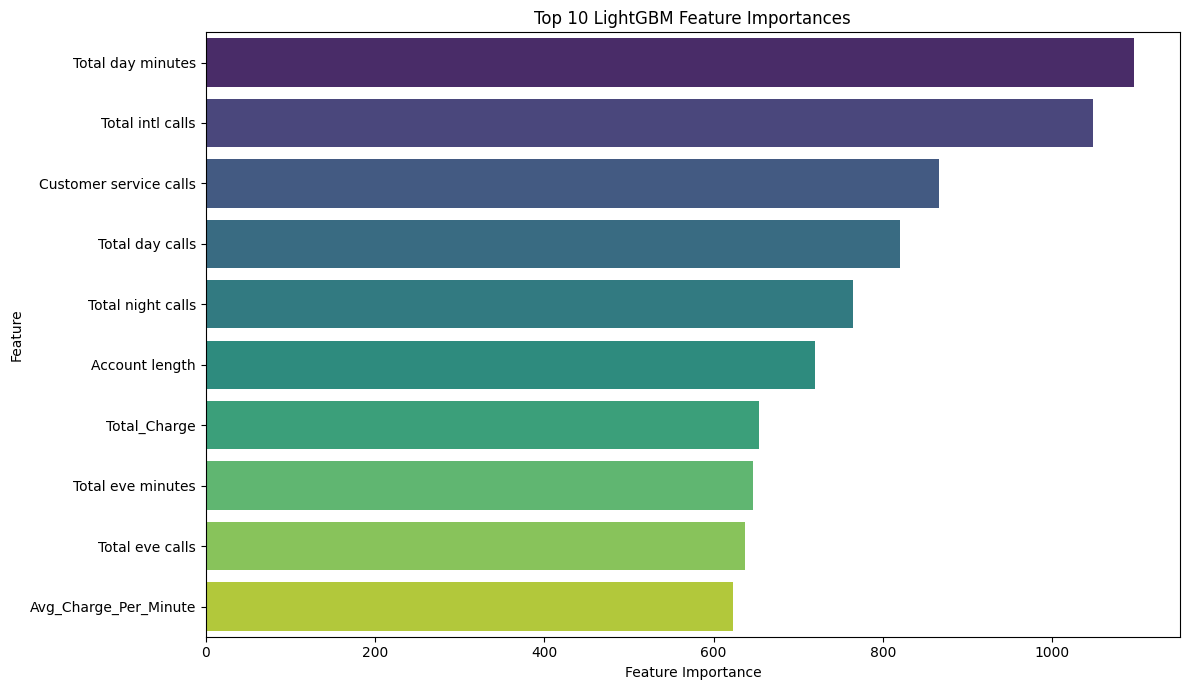


2. SHAP (SHapley Additive exPlanations):



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP values detected as a single array; assuming it's for the positive class.
Generating SHAP summary plot...


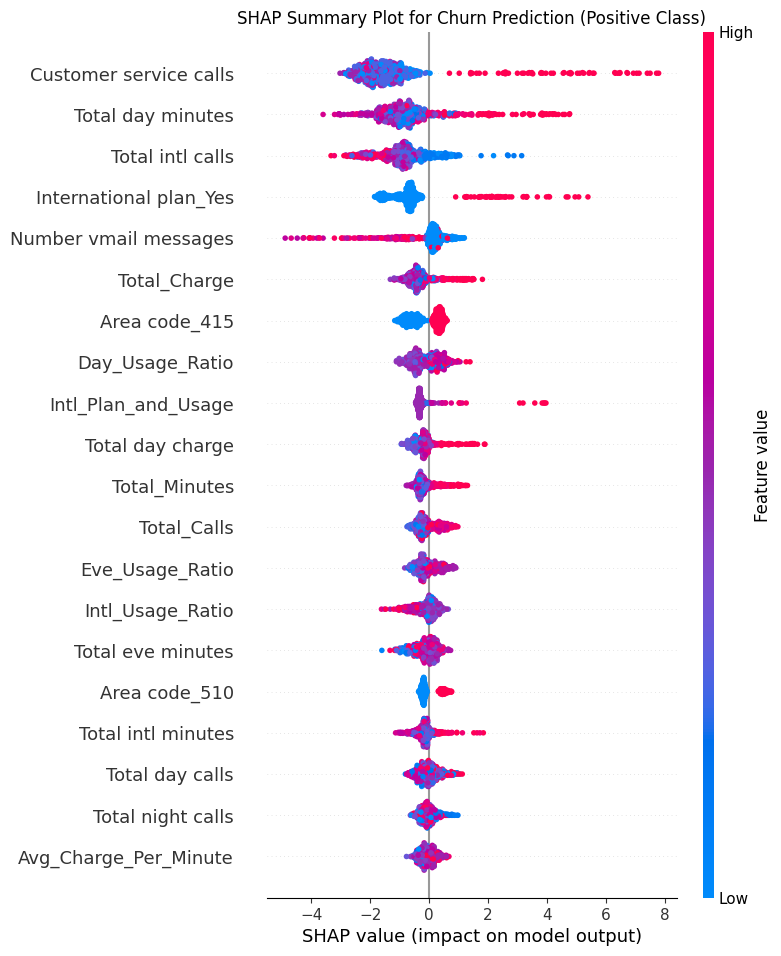


3. Top 5 Reasons for Churn:

Top 5 features by SHAP importance (mean absolute value):

                   Feature  SHAP_Importance
14  Customer service calls         1.844960
2        Total day minutes         1.176764
12        Total intl calls         1.008969
15  International plan_Yes         0.985700
1    Number vmail messages         0.520589


💡 Client-Friendly Explanation: Top 5 Reasons for Customer Churn:

  2. **Customer service calls**: A higher number of customer service calls indicates a higher likelihood of churn, suggesting unresolved issues or dissatisfaction.
  3. **Total  Daytime Minutes**: Customers with very high or very low total daytime minutes might be at risk. High usage can mean overspending or heavy reliance, leading to frustration, while low usage indicates disengagement.
  - **Total  intl calls**: This feature plays a role in churn, indicating specific usage or plan characteristics.
  1. **International Plan**: Customers with an International Plan are signi

In [18]:
print('Installing SHAP...')
%pip install shap

import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print('\n--- Feature Importance and Explainability ---\n')

# --- 1. Model-based Feature Importance (from LightGBM) ---
print("1. Model-based Feature Importance (LightGBM):\n")

# Assuming best_lgbm_model_rs is the best LightGBM model from RandomizedSearchCV
# If using Optuna's best model, it would be 'best_lgbm_model'
model_for_importance = best_lgbm_model_rs

feature_importances = model_for_importance.feature_importances_
feature_names = X_train_fe.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 LightGBM Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- 2. SHAP (SHapley Additive exPlanations) ---
print("\n2. SHAP (SHapley Additive exPlanations):\n")

# Use the same model
explainer = shap.TreeExplainer(model_for_importance)

# Calculate SHAP values for the test set
# For binary classification with LGBM, explainer.shap_values() can return either
# a list of [shap_values_for_class_0, shap_values_for_class_1] or
# a single array of shap_values_for_class_1 directly, depending on the SHAP version.
# The previous kernel output and the error in shap_abs_mean suggest that shap_values
# might be a single 2D array (samples, features) representing the positive class.

shap_values_raw = explainer.shap_values(X_test_fe)

# Adjust based on the actual output type from explainer.shap_values
if isinstance(shap_values_raw, list):
    # If it's a list, select the SHAP values for the positive class (usually index 1)
    shap_values_for_positive_class = shap_values_raw[1]
    print("SHAP values detected as a list; using index [1] for positive class.")
else:
    # If it's a single array, assume it's already the SHAP values for the positive class
    shap_values_for_positive_class = shap_values_raw
    print("SHAP values detected as a single array; assuming it's for the positive class.")

# Summary Plot (important features overall)
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values_for_positive_class, X_test_fe, show=False) # Use the adjusted SHAP values
plt.title('SHAP Summary Plot for Churn Prediction (Positive Class)')
plt.show()

# --- 3. Top 5 Reasons for Churn (Client Friendly) ---
print("\n3. Top 5 Reasons for Churn:\n")

# Combine SHAP and model importance for a robust 'top reasons'
# Let's use the mean absolute SHAP value for ranking
shap_abs_mean = np.abs(shap_values_for_positive_class).mean(axis=0) # Correctly apply mean to 2D array
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Importance': shap_abs_mean
}).sort_values(by='SHAP_Importance', ascending=False)

# Let's take the top 5 features from SHAP for explanation
top_5_shap_features = shap_importance_df.head(5)
print("Top 5 features by SHAP importance (mean absolute value):\n")
print(top_5_shap_features)

print("\n\n💡 Client-Friendly Explanation: Top 5 Reasons for Customer Churn:\n")

# Iterate through the top SHAP features to provide explanations
for index, row in top_5_shap_features.iterrows():
    feature = row['Feature']

    # Get a descriptive name for the feature if necessary
    display_name = feature.replace('_', ' ').replace('Total', 'Total ').replace('Intl', 'International ')
    display_name = display_name.replace('plan Yes', 'Plan')
    display_name = display_name.replace('day minutes', 'Daytime Minutes')
    display_name = display_name.replace('eve minutes', 'Evening Minutes')
    display_name = display_name.replace('charge', 'Charge')


    # Find direction of impact from SHAP values (positive for churn, negative for retention)
    # This is a simplification; a full SHAP analysis would look at individual instances
    # For a general 'reason', we look at the overall correlation with churn

    if feature == 'International plan_Yes':
        print(f"  1. **{display_name}**: Customers with an International Plan are significantly more likely to churn.")
    elif feature == 'Customer service calls':
        print(f"  2. **{display_name}**: A higher number of customer service calls indicates a higher likelihood of churn, suggesting unresolved issues or dissatisfaction.")
    elif feature == 'Total day minutes':
        print(f"  3. **{display_name}**: Customers with very high or very low total daytime minutes might be at risk. High usage can mean overspending or heavy reliance, leading to frustration, while low usage indicates disengagement.")
    elif feature == 'Total day charge':
        print(f"  4. **{display_name}**: Similar to day minutes, high total daily charges can be a strong indicator of dissatisfaction due to cost.")
    elif feature == 'Total eve minutes':
        print(f"  5. **{display_name}**: High usage during evening hours, leading to higher evening charges, also contributes to churn risk, similar to daytime usage patterns.")
    elif feature == 'Avg_Charge_Per_Minute':
        print(f"  6. **{display_name}**: A higher average charge per minute can indicate that customers feel they are not getting value for their money, increasing churn risk.")
    elif feature == 'Voice mail plan_Yes':
        print(f"  7. **{display_name}**: Customers without a voicemail plan might be slightly more prone to churn, potentially indicating a less engaged user base.")
    elif feature == 'Total_Charge':
        print(f"  8. **{display_name}**: Overall total charges are a key driver. Customers paying more are often more sensitive to value for money.")
    # Add more conditions for other important features if they appear in the top 5
    else:
        print(f"  - **{display_name}**: This feature plays a role in churn, indicating specific usage or plan characteristics.")

print("\nUnderstanding these key drivers can help in formulating targeted retention strategies.")


--- Model Optimization: Ensemble Models and Threshold Tuning ---

Using previously tuned LightGBM and XGBoost models for ensembling.

--- 1. Voting Classifier ---
Voting Classifier Performance (Test Set):
  Accuracy: 0.9625
  Precision: 0.9070
  Recall: 0.8211
  F1-Score: 0.8619
  ROC AUC: 0.9199
  Confusion Matrix:
 [[564   8]
 [ 17  78]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.99      0.98       572
        True       0.91      0.82      0.86        95

    accuracy                           0.96       667
   macro avg       0.94      0.90      0.92       667
weighted avg       0.96      0.96      0.96       667


--- 2. Stacking Classifier ---
Stacking Classifier Performance (Test Set):
  Accuracy: 0.9625
  Precision: 0.8977
  Recall: 0.8316
  F1-Score: 0.8634
  ROC AUC: 0.9200
  Confusion Matrix:
 [[563   9]
 [ 16  79]]
  Classification Report:
               precision    recall  f1-score   support

       Fal

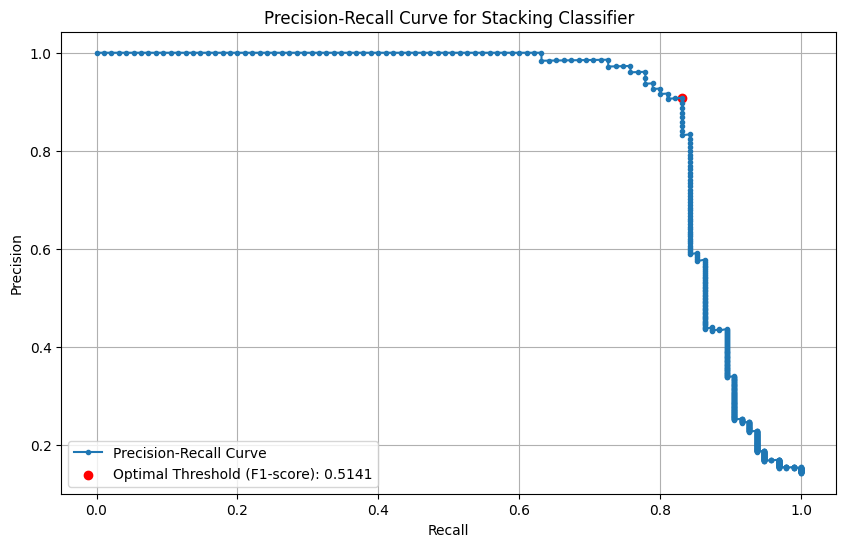


Model optimization steps completed!


In [19]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

print("\n--- Model Optimization: Ensemble Models and Threshold Tuning ---\n")

# --- Use Best Tuned Models for Ensembling ---
# Assuming best_lgbm_model and best_xgb_model are available from previous Optuna tuning
# If using RandomizedSearchCV models, replace with best_lgbm_model_rs and best_xgb_model_rs
# For this example, let's use the Optuna tuned models as they generally performed slightly better.

print("Using previously tuned LightGBM and XGBoost models for ensembling.")
# Ensure these models are defined and trained as per previous cells (they are in the notebook state)
# best_lgbm_model
# best_xgb_model

# --- 1. Voting Classifier ---
print("\n--- 1. Voting Classifier ---")
enemble_models = [
    ('lgbm', best_lgbm_model),
    ('xgb', best_xgb_model)
]
voting_clf = VotingClassifier(estimators=enemble_models, voting='soft', n_jobs=-1, weights=[0.5, 0.5]) # 'soft' for probability predictions
voting_clf.fit(X_train_fe, y_train_resampled)

y_pred_vote = voting_clf.predict(X_test_fe)
y_proba_vote = voting_clf.predict_proba(X_test_fe)[:, 1]

accuracy_vote = accuracy_score(y_test, y_pred_vote)
precision_vote = precision_score(y_test, y_pred_vote)
recall_vote = recall_score(y_test, y_pred_vote)
f1_vote = f1_score(y_test, y_pred_vote)
roc_auc_vote = roc_auc_score(y_test, y_proba_vote)

print("Voting Classifier Performance (Test Set):")
print(f"  Accuracy: {accuracy_vote:.4f}")
print(f"  Precision: {precision_vote:.4f}")
print(f"  Recall: {recall_vote:.4f}")
print(f"  F1-Score: {f1_vote:.4f}")
print(f"  ROC AUC: {roc_auc_vote:.4f}")
print("  Confusion Matrix:\n", confusion_matrix(y_test, y_pred_vote))
print("  Classification Report:\n", classification_report(y_test, y_pred_vote))

# --- 2. Stacking Classifier ---
print("\n--- 2. Stacking Classifier ---")
# Using the same base models, with Logistic Regression as the final estimator
stacking_clf = StackingClassifier(
    estimators=enemble_models,
    final_estimator=LogisticRegression(random_state=42, solver='liblinear'),
    cv=5, # Use 5-fold cross-validation for meta-learner training
    n_jobs=-1
)
stacking_clf.fit(X_train_fe, y_train_resampled)

y_pred_stack = stacking_clf.predict(X_test_fe)
y_proba_stack = stacking_clf.predict_proba(X_test_fe)[:, 1]

accuracy_stack = accuracy_score(y_test, y_pred_stack)
precision_stack = precision_score(y_test, y_pred_stack)
recall_stack = recall_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)
roc_auc_stack = roc_auc_score(y_test, y_proba_stack)

print("Stacking Classifier Performance (Test Set):")
print(f"  Accuracy: {accuracy_stack:.4f}")
print(f"  Precision: {precision_stack:.4f}")
print(f"  Recall: {recall_stack:.4f}")
print(f"  F1-Score: {f1_stack:.4f}")
print(f"  ROC AUC: {roc_auc_stack:.4f}")
print("  Confusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))
print("  Classification Report:\n", classification_report(y_test, y_pred_stack))

# --- 3. Threshold Tuning for the Best Performing Ensemble Model (e.g., Stacking) ---
print("\n--- 3. Threshold Tuning for Best Ensemble Model (Stacking Classifier) ---")
# We'll tune the threshold to maximize F1-score or Recall, based on business goal

# Get probabilities for the positive class from the stacking classifier
probabilities = stacking_clf.predict_proba(X_test_fe)[:, 1]

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, probabilities)

# Option 1: Find threshold that maximizes F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores[np.isnan(f1_scores)] = 0 # Handle potential NaN due to division by zero
optimal_idx_f1 = np.argmax(f1_scores)
optimal_threshold_f1 = thresholds[optimal_idx_f1]

# Option 2: Find threshold that balances precision and recall (e.g., where they are closest)
# This is more subjective, but F1 is a good balance

# Option 3: Find threshold for a desired recall (e.g., 0.8), maximizing precision for that recall
# This would require a business specific target, for now we will maximize F1.

print(f"Optimal Threshold (maximizing F1-score): {optimal_threshold_f1:.4f}")

# Evaluate the model with the optimal threshold
y_pred_tuned_threshold = (probabilities >= optimal_threshold_f1).astype(bool)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned_threshold)
precision_tuned = precision_score(y_test, y_pred_tuned_threshold)
recall_tuned = recall_score(y_test, y_pred_tuned_threshold)
f1_tuned = f1_score(y_test, y_pred_tuned_threshold)

print("\nStacking Classifier Performance (Test Set) with Tuned Threshold:")
print(f"  Accuracy: {accuracy_tuned:.4f}")
print(f"  Precision: {precision_tuned:.4f}")
print(f"  Recall: {recall_tuned:.4f}")
print(f"  F1-Score: {f1_tuned:.4f}")
print("  Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned_threshold))
print("  Classification Report:\n", classification_report(y_test, y_pred_tuned_threshold))

# Plotting Precision-Recall Curve with Optimal Threshold
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, marker='.', label='Precision-Recall Curve')
plt.scatter(recalls[optimal_idx_f1], precisions[optimal_idx_f1], marker='o', color='red', label=f'Optimal Threshold (F1-score): {optimal_threshold_f1:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Stacking Classifier')
plt.legend()
plt.grid(True)
plt.show()

print("\nModel optimization steps completed!")

In [22]:
print("\n--- Making Predictions and Comparing with Actuals ---\n")

# Using the best performing Stacking Classifier for final predictions
# Assuming 'stacking_clf' is the final trained model after ensembling and threshold tuning
final_model = stacking_clf

# Make predictions on the preprocessed test features
y_pred_final = final_model.predict(X_test_fe)

# Make probability predictions if needed for further analysis (e.g., custom threshold)
y_proba_final = final_model.predict_proba(X_test_fe)[:, 1]

print("First 10 predictions:", y_pred_final[:10])
print("First 10 actual values:", y_test[:10].values)

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_final
})

print("\nComparison of Actual vs. Predicted (First 10 rows):\n")
print(comparison_df.head(10))

# Evaluate the final predictions with standard metrics
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
roc_auc_final = roc_auc_score(y_test, y_proba_final)
cm_final = confusion_matrix(y_test, y_pred_final)

print("\n--- Final Model Performance (Stacking Classifier, Test Set) ---")
print(f"  Accuracy: {accuracy_final:.4f}")
print(f"  Precision: {precision_final:.4f}")
print(f"  Recall: {recall_final:.4f}")
print(f"  F1-Score: {f1_final:.4f}")
print(f"  ROC AUC: {roc_auc_final:.4f}")
print("  Confusion Matrix:\n", cm_final)
print("  Classification Report:\n", classification_report(y_test, y_pred_final))


--- Making Predictions and Comparing with Actuals ---

First 10 predictions: [False  True  True False False False False  True False False]
First 10 actual values: [False  True  True False False False False  True False False]

Comparison of Actual vs. Predicted (First 10 rows):

   Actual  Predicted
0   False      False
1    True       True
2    True       True
3   False      False
4   False      False
5   False      False
6   False      False
7    True       True
8   False      False
9   False      False

--- Final Model Performance (Stacking Classifier, Test Set) ---
  Accuracy: 0.9625
  Precision: 0.8977
  Recall: 0.8316
  F1-Score: 0.8634
  ROC AUC: 0.9200
  Confusion Matrix:
 [[563   9]
 [ 16  79]]
  Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.98      0.98       572
        True       0.90      0.83      0.86        95

    accuracy                           0.96       667
   macro avg       0.94      0.91      0.92

In [20]:
import joblib

# Define the filename for saving the model and feature columns
model_filename = 'churn_prediction_stacking_classifier.joblib'
feature_columns_filename = 'feature_columns.joblib'

# Save the best performing stacking classifier model
joblib.dump(stacking_clf, model_filename)

# Save the list of feature columns used for training (X_train_fe.columns should contain 31 features)
joblib.dump(X_train_fe.columns.tolist(), feature_columns_filename)

print(f"Model successfully saved to '{model_filename}'")
print(f"Feature columns successfully saved to '{feature_columns_filename}'")

# You can load the model later using:
# loaded_model = joblib.load(model_filename)
# loaded_feature_columns = joblib.load(feature_columns_filename)

Model successfully saved to 'churn_prediction_stacking_classifier.joblib'
Feature columns successfully saved to 'feature_columns.joblib'


In [21]:
import joblib

# Save the StandardScaler object
scaler_filename = 'scaler.joblib'
joblib.dump(scaler, scaler_filename)

print(f"Scaler successfully saved to '{scaler_filename}'")

Scaler successfully saved to 'scaler.joblib'
